In [1]:
import pandas as pd
import math
import numpy as np
from numpy.fft import rfft, rfftfreq
from numpy.lib.stride_tricks import as_strided
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator, MultipleLocator, AutoMinorLocator
import matplotlib.animation as animation
import scipy
from scipy import stats
from scipy.signal import welch, stft, spectrogram, butter, sosfiltfilt, get_window
from scipy.stats import chi2
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import os
from datetime import datetime, timedelta
import re
import pywt
import copy
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from IPython.display import clear_output

# Requires the published 'decode-wfs' package. Install it with `pip install decode-wfs`.
from decode_wfs import load_continuous

mpl.rcParams['agg.path.chunksize'] = 10000000
from pathlib import Path

In [2]:
label_size=14
tick_size=12
figure_dpi=150

## Load LVM file

In [3]:
trigger_shifted = False
data_trimmed = False
ae_synced_on_peak = False

while True:
    filepath = input("Enter the absolute path to lvm file: ").strip().strip('"')
    if os.path.isfile(filepath) and filepath.endswith(".lvm"):
        break
    print("Invalid file. Try again.")

print(f"Using file: {filepath}")

# Set up output directory and save function for images
lvm_path = Path(filepath).expanduser().resolve()
img_dir = lvm_path.parent / "imgs"
img_dir.mkdir(exist_ok=True)

lvm_stem = lvm_path.stem

def add_ae_sync_note(fig):
    for text in list(fig.texts):
        if text.get_gid() == "ae_sync_note":
            text.remove()

    if ae_synced_on_peak:
        return

    note = fig.text(
        0.995,
        0.005,
        "AE not synchronized to hydrophone peak",
        ha="right",
        va="bottom",
        fontsize=7,
        color="firebrick",
        bbox={"facecolor": "white", "edgecolor": "firebrick", "alpha": 0.75, "boxstyle": "round,pad=0.15"},
    )
    note.set_gid("ae_sync_note")


def save_figure(fig, suffix, category, stem=lvm_stem, dpi=figure_dpi, includes_ae=False):
    if includes_ae:
        add_ae_sync_note(fig)

    category_dir = img_dir / category
    category_dir.mkdir(exist_ok=True)
    out_path = category_dir / f"{stem}_{suffix}.png"

    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {out_path}")
    return out_path


# Find the header line and parse column names
header_line = None
start_line = None
with open(filepath, "r") as f:
    for i, line in enumerate(f):
        if line.strip().startswith("X_Value"):
            header_line = line
            start_line = i + 1
            break

if start_line is None:
    raise ValueError("Couldn't find the 'X_Value' header line in the file.")

# Parse column names from header
col_names = [c.strip() for c in header_line.split(",")]

# Identify indices of the columns we care about
REQUIRED = ["X_Value", "Voltage"]          # adjust "Voltage" to match your actual header name
OPTIONAL = ["Trigger Voltage"]

wanted = REQUIRED + [c for c in OPTIONAL if c in col_names]
usecols = [col_names.index(c) for c in wanted]

# Load only the columns we want
lvm_data = np.loadtxt(filepath, delimiter=",", skiprows=start_line, usecols=usecols)

# Build a dict for clean, name-based access
channels = {name: lvm_data[:, i] for i, name in enumerate(wanted)}

# Normalize signal
channels["Voltage"] -= channels["Voltage"].mean()

# Check if optional column was loaded
has_trigger = "Trigger Voltage" in channels
if has_trigger:
    print("Trigger Voltage column detected.")

hydrophone_sample_rate = 1 / np.mean(np.diff(channels["X_Value"]))
print(f"Estimated sampling frequency: {hydrophone_sample_rate:.2f} Hz")

# Preview
header = f"{'Row':<6} {'Time (s)':>14} {'Voltage (V)':>14}"
if has_trigger:
    header += f" {'Trigger (V)':>14}"
print(f"\n{header}")
print("-" * (36 + 15 * has_trigger))
for i in range(min(10, lvm_data.shape[0])):
    row = f"{i:<6} {channels['X_Value'][i]:>14.6f} {channels['Voltage'][i]:>14.6f}"
    if has_trigger:
        row += f" {channels['Trigger Voltage'][i]:>14.6f}"
    print(row)

def highpass_filter(signal, cutoff_hz, fs, order=4):
    sos = butter(order, cutoff_hz, btype='high', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)

# High-pass filter to remove frequencies below a cutoff frequency
cutoff_freq = 600.0  # Hz
high_pass_lvm_data = lvm_data.copy()
high_pass_lvm_data[:, 1] = highpass_filter(lvm_data[:, 1], cutoff_freq, hydrophone_sample_rate)

Using file: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\PD-acoustic-EMPIRE_12.lvm
Trigger Voltage column detected.
Estimated sampling frequency: 12800.00 Hz

Row          Time (s)    Voltage (V)    Trigger (V)
---------------------------------------------------
0            0.000000       0.011872      -0.001847
1            0.000078       0.012364      -0.001798
2            0.000156       0.013514      -0.001592
3            0.000234       0.014206      -0.001626
4            0.000312       0.014029      -0.002080
5            0.000391       0.013308      -0.002335
6            0.000469       0.013259      -0.002193
7            0.000547       0.012766      -0.001862
8            0.000625       0.011398      -0.001911
9            0.000703       0.008598      -0.001982


## Determine time of external trigger pulse, if present

In [4]:
first_trigger_time = None  # default
if has_trigger:
    threshold = 0.001  # V
    trigger_indices = np.where(channels["Trigger Voltage"] > threshold)[0]

    if len(trigger_indices) == 0:
        print(f"Trigger voltage never exceeded {threshold} V.")
    else:
        first_trigger_idx = trigger_indices[0]
        first_trigger_time = channels["X_Value"][first_trigger_idx]
        print(f"Trigger voltage first exceeded {threshold} V at t = {first_trigger_time:.6f} s "
              f"(sample {first_trigger_idx})")

    # fig, ax = plt.subplots(figsize=(12, 3))
    # ax.plot(channels["X_Value"], channels["Trigger Voltage"], color="tab:orange", linewidth=0.8)
    # ax.set_xlabel("Time (s)")
    # ax.set_ylabel("Trigger Voltage (V)")
    # ax.set_title("Trigger Voltage over Time")
    # ax.grid(True, linestyle="--", alpha=0.5)
    # plt.tight_layout()
    # plt.show()

Trigger voltage never exceeded 0.001 V.


## Zero LVM time column on instant of external trigger pulse, if present

First 10 rows of corrected data:
Row          Time (s)    Voltage (V)    Trigger (V)
---------------------------------------------------
0            0.000000       0.011872      -0.001847
1            0.000078       0.012364      -0.001798
2            0.000156       0.013514      -0.001592
3            0.000234       0.014206      -0.001626
4            0.000312       0.014029      -0.002080
5            0.000391       0.013308      -0.002335
6            0.000469       0.013259      -0.002193
7            0.000547       0.012766      -0.001862
8            0.000625       0.011398      -0.001911
9            0.000703       0.008598      -0.001982


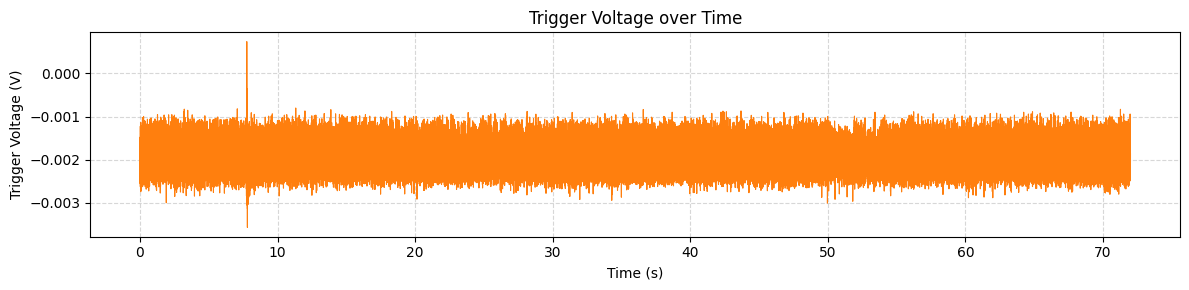

In [5]:
if not trigger_shifted and first_trigger_time is not None:
    print(f"Applying baseline correction using trigger period (t0 = {first_trigger_time:.6f} s)\n")
    lvm_data[:, 0] = lvm_data[:, 0] - first_trigger_time  # baseline correction using trigger period
    high_pass_lvm_data[:, 0] = high_pass_lvm_data[:, 0] - first_trigger_time  # also shift the high-pass filtered data
    trigger_shifted = True

# Print first few rows of the corrected data
print("First 10 rows of corrected data:")
header = f"{'Row':<6} {'Time (s)':>14} {'Voltage (V)':>14}"
if has_trigger:
    header += f" {'Trigger (V)':>14}"
print(f"{header}")
print("-" * (36 + 15 * has_trigger))
for i in range(min(10, lvm_data.shape[0])):
    row = f"{i:<6} {lvm_data[i, 0]:>14.6f} {lvm_data[i, 1]:>14.6f}"
    if has_trigger:
        row += f" {lvm_data[i, 2]:>14.6f}"
    print(row)

if has_trigger:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(lvm_data[:, 0], lvm_data[:, 2], color="tab:orange", linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Trigger Voltage (V)")
    ax.set_title("Trigger Voltage over Time")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## Load WFS file

In [6]:
waveform_load_mode = "wfs"  # Change to "csv" to use the legacy CSV/pickle workflow.
wfs_channel = 1
wfs_use_record_positions = False

def parse_wfs_start_time(wfs_path):
    name = Path(wfs_path).name
    match = re.search(r"(\d{2})(\d{2})(\d{2})(?:-\d+)?\.wfs$", name, re.IGNORECASE)
    if match is None:
        return None
    hours, minutes, seconds = map(int, match.groups())
    return datetime(1900, 1, 1, hour=hours, minute=minutes, second=seconds)

# 1) Ask for the waveform source path
if waveform_load_mode == "csv":
    while True:
        folder_path = input("Enter the absolute path to the waveform CSV folder ...").strip().strip('"')
        if os.path.isdir(folder_path):
            break
        print("Invalid directory. Try again.")

    print(f"Using folder: {folder_path}")
elif waveform_load_mode == "wfs":
    while True:
        wfs_path = input("Enter the absolute path to the .wfs file ...").strip().strip('"')
        if os.path.isfile(wfs_path) and wfs_path.lower().endswith('.wfs'):
            wfs_path = str(Path(wfs_path).expanduser().resolve())
            folder_path = str(Path(wfs_path).parent)
            break
        print("Invalid .wfs file. Try again.")

    print(f"Using .wfs file: {wfs_path}")
else:
    raise ValueError(f"Unsupported waveform_load_mode: {waveform_load_mode}")

print(f"Waveform load mode: {waveform_load_mode}")

Using .wfs file: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\STREAM20260507-173632-763.wfs
Waveform load mode: wfs


In [7]:
# Shared file names for the two waveform-loading modes
base_name = os.path.basename(folder_path)
pickle_file = os.path.join(folder_path, base_name + '_combined.pkl')


# 2) Load the data based on the selected mode
if waveform_load_mode == "csv":
    def sort_key(fn):
        base = os.path.splitext(fn)[0]
        parts = base.split('_')
        try:
            return int(parts[-2])
        except Exception:
            return 0

    csv_files = sorted(
        [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')],
        key=sort_key
    )
    if not csv_files:
        raise RuntimeError("No CSVs found.")

    first_csv = os.path.join(folder_path, csv_files[0])
    with open(first_csv, 'r') as f:
        header = [next(f) for _ in range(12)]
    sample_interval = float(header[3].split(':')[-1].strip())
    print("Sample interval (s):", sample_interval)

    # 4) Try loading the pickle, otherwise build & cache
    if os.path.isfile(pickle_file):
        print("Loading cached array...")
        with open(pickle_file, 'rb') as pf:
            loaded_item = pickle.load(pf)

        if isinstance(loaded_item, dict):
            ae_data = loaded_item["combined_data"]
            sample_interval = loaded_item.get("sample_interval", sample_interval)
        else:
            ae_data = loaded_item
    else:
        data_list = []
        for fn in tqdm(csv_files, desc="Reading CSVs"):
            path = os.path.join(folder_path, fn)
            arr = np.loadtxt(path, delimiter=',', skiprows=12)
            data_list.append(arr)

        ae_data = np.vstack(data_list)
        print("Saving cache...")
        with open(pickle_file, 'wb') as pf:
            pickle.dump(ae_data, pf)

elif waveform_load_mode == "wfs":
    if 'wfs_path' not in globals():
        raise ValueError("Run the waveform path cell first to set wfs_path.")
    data, t, sr = load_continuous(
        wfs_path,
        channel=wfs_channel,
        use_record_positions=wfs_use_record_positions,
    )
    ae_data = np.column_stack((t, data))
    sample_interval = 1.0 / float(sr)
    print("WFS sample interval (s):", sample_interval)
else:
    raise ValueError(f"Unsupported waveform_load_mode: {waveform_load_mode}")

print("ae_data type:", type(ae_data))
print("ae_data shape:", ae_data.shape)

print(f"Sampling Interval: {sample_interval} s")
ae_sample_rate = 1 / sample_interval
print(f"Sampling Frequency: {ae_sample_rate} Hz")

C:\Users\sapierso\AppData\Local\Temp\ipykernel_50104\2467563417.py:55: UserWarning: Applied AEwin64 stream start offset: 2,072 samples
  data, t, sr = load_continuous(


WFS sample interval (s): 1e-06
ae_data type: <class 'numpy.ndarray'>
ae_data shape: (62162920, 2)
Sampling Interval: 1e-06 s
Sampling Frequency: 1000000.0 Hz


## Plot the Hydrophone and AE Signal

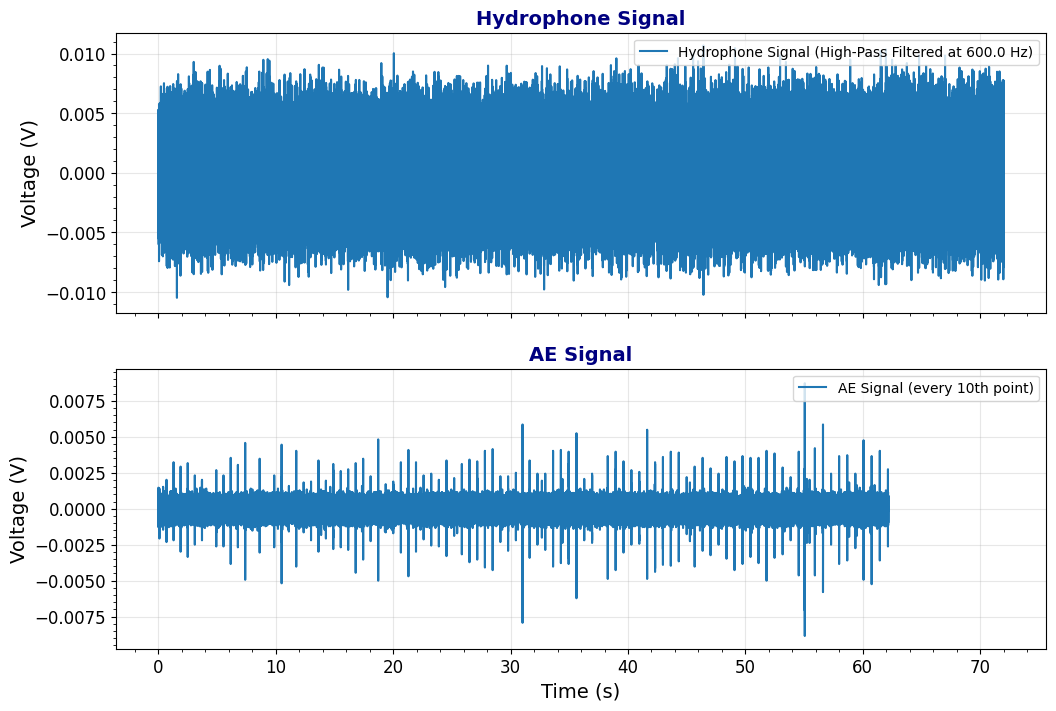

In [8]:
def plot_signals(lvm_data, ae_data, lvm_label: str = "Hydrophone Signal",
                 lvm_marker: float = None, ae_marker: float = None, ae_step: int = 10, legend_loc="upper left",
                 sup_title=None):
    x_ds = ae_data[::ae_step, 0]
    y_ds = ae_data[::ae_step, 1]

    if ae_step == 1:
        ae_label = "AE Signal"
    else:
        if ae_step % 100 in (11, 12, 13):  # Special case for 11th, 12th, 13th
            suffix = "th"
        elif ae_step % 10 == 1:
            suffix = "st"
        elif ae_step % 10 == 2:
            suffix = "nd"
        elif ae_step % 10 == 3:
            suffix = "rd"
        else:
            suffix = "th"
            
        ae_label = f"AE Signal (every {ae_step}{suffix} point)"

    y_padding = 1.1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(lvm_data[:, 0], lvm_data[:, 1], label=lvm_label)
    if lvm_marker is not None:
        ax1.axvline(x=lvm_marker, color='red', linestyle='--', label=f"Marker at {lvm_marker:.3f}s", alpha=0.7)
    lvm_abs_max = np.max(np.abs(lvm_data[:, 1]))
    ax1.set_ylim(-lvm_abs_max * y_padding, lvm_abs_max * y_padding)
    ax1.set_ylabel('Voltage (V)', fontsize=label_size)
    ax1.set_title('Hydrophone Signal', fontsize=label_size, fontweight='bold', color='navy')
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.tick_params(axis='both', which='major', labelsize=tick_size)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc=legend_loc)

    ax2.plot(x_ds, y_ds, label=ae_label)
    if ae_marker is not None:
        ax2.axvline(x=ae_marker, color='red', linestyle='--', label=f"Marker at {ae_marker:.3f}s", alpha=0.7)
    ae_abs_max = np.max(np.abs(y_ds))
    ax2.set_ylim(-ae_abs_max * y_padding, ae_abs_max * y_padding)
    ax2.set_xlabel("Time (s)", fontsize=label_size)
    ax2.set_ylabel("Voltage (V)", fontsize=label_size)
    ax2.set_title("AE Signal", fontsize=label_size, fontweight='bold', color='navy')
    ax2.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
    ax2.xaxis.set_minor_locator(AutoMinorLocator())
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.tick_params(axis='both', which='major', labelsize=tick_size)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc=legend_loc)

    if sup_title is not None:
        fig.suptitle(sup_title, fontsize=16, fontweight='bold', y=0.95)

    return fig, (ax1, ax2)

plot_signals(high_pass_lvm_data, ae_data, lvm_label=f"Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)", ae_step=10, legend_loc="upper right")
plt.show()

## Synchronize AE to Hydrophone Time

In [9]:
## Ask User Whether to Synchronize Hydrophone and AE on a Peak
while True:
    sync_data = input("Do you want to synchronize Hydrophone and AE on a peak? (y/n): ").strip().lower()
    if sync_data in ['y', 'n']:
        break

In [10]:
hydrophone_threshold = 0.5  # V
ae_threshold = 0.5  # V 
if sync_data == 'y':  
    extra_msg = ""  # carries forward any error/warning into the next prompt
    while True:
        status_lines = []
        first_hydrophone_peak_time = None
        first_ae_peak_time = None

        # Carry any message from the previous iteration into this prompt
        if extra_msg:
            status_lines.append(extra_msg)
            extra_msg = ""

        # --- Find hydrophone peak ---
        hydrophone_indices = np.where(np.abs(high_pass_lvm_data[:, 1]) > hydrophone_threshold)[0]
        if len(hydrophone_indices) == 0:
            status_lines.append(f"No hydrophone peaks found above {hydrophone_threshold} V.")
        else:
            first_hydrophone_peak_index = hydrophone_indices[0]
            first_hydrophone_peak_time = high_pass_lvm_data[first_hydrophone_peak_index, 0]
            # status_lines.append(
            #     f"Hydrophone peak above {hydrophone_threshold} V at "
            #     f"t = {first_hydrophone_peak_time:.6f} s (sample {first_hydrophone_peak_index})."
            # )

        # --- Find AE peak ---
        ae_indices = np.where(np.abs(ae_data[:, 1]) > ae_threshold)[0]
        if len(ae_indices) == 0:
            status_lines.append(f"No AE peaks found above {ae_threshold} V.")
        else:
            first_ae_peak_index = ae_indices[0]
            first_ae_peak_time = ae_data[first_ae_peak_index, 0]
            # status_lines.append(
            #     f"AE peak above {ae_threshold} V at "
            #     f"t = {first_ae_peak_time:.6f} s (sample {first_ae_peak_index})."
            # )

        both_found = first_hydrophone_peak_time is not None and first_ae_peak_time is not None

        # --- Plot preview ---
        if both_found:
            time_desync = first_hydrophone_peak_time - first_ae_peak_time
            mod_ae_data = copy.deepcopy(ae_data)
            mod_ae_data[:, 0] += time_desync
            plt.close('all')
            clear_output(wait=True)
            plot_signals(high_pass_lvm_data, mod_ae_data,
                         lvm_marker=first_hydrophone_peak_time,
                         ae_marker=first_ae_peak_time + time_desync,  # adjusted to mod_ae_data's time axis
                         ae_step=10,
                         legend_loc="upper right")
            plt.show()
        else:
            plt.close('all')
            clear_output(wait=True)
            plot_signals(high_pass_lvm_data, ae_data, ae_step=10, legend_loc="upper right")
            plt.show()

        # --- Build and show prompt ---
        done_option = " 'done' to apply sync," if both_found else ""
        prompt = (
            "\n".join(status_lines) + "\n"
            f"Enter new thresholds as 'hydro ae' (e.g. '0.3 0.7'),{done_option} or 'quit' to abort: "
        )

        raw = input(prompt).strip()

        if raw.lower() == 'quit':
            print("Sync aborted.")
            break
        elif raw.lower() == 'done':
            if both_found:
                # Apply sync to ae_data and show final plot
                ae_data[:, 0] += time_desync
                ae_synced_on_peak = True
                plt.close('all')
                clear_output(wait=True)
                print(f"Synced ae_data with adjustment of {time_desync:.6f} s. Showing final plot...")
                plot_signals(high_pass_lvm_data, ae_data,
                             lvm_marker=first_hydrophone_peak_time,
                             ae_marker=first_ae_peak_time + time_desync,  # adjusted to mod_ae_data's time axis
                             ae_step=10,
                             legend_loc="upper right")
                plt.show()
                break
            else:
                extra_msg = "'done' is only available when peaks are found for both signals."
        else:
            try:
                hydrophone_threshold, ae_threshold = map(float, raw.split())
            except ValueError:
                extra_msg = f"Invalid input '{raw}' — expected two numbers separated by a space (e.g. '0.3 0.7')."

## Trim Signals to Same Duration

Hydrophone data time range: 0.000000 s to 71.999922 s
AE data time range: -0.001024 s to 62.161895 s


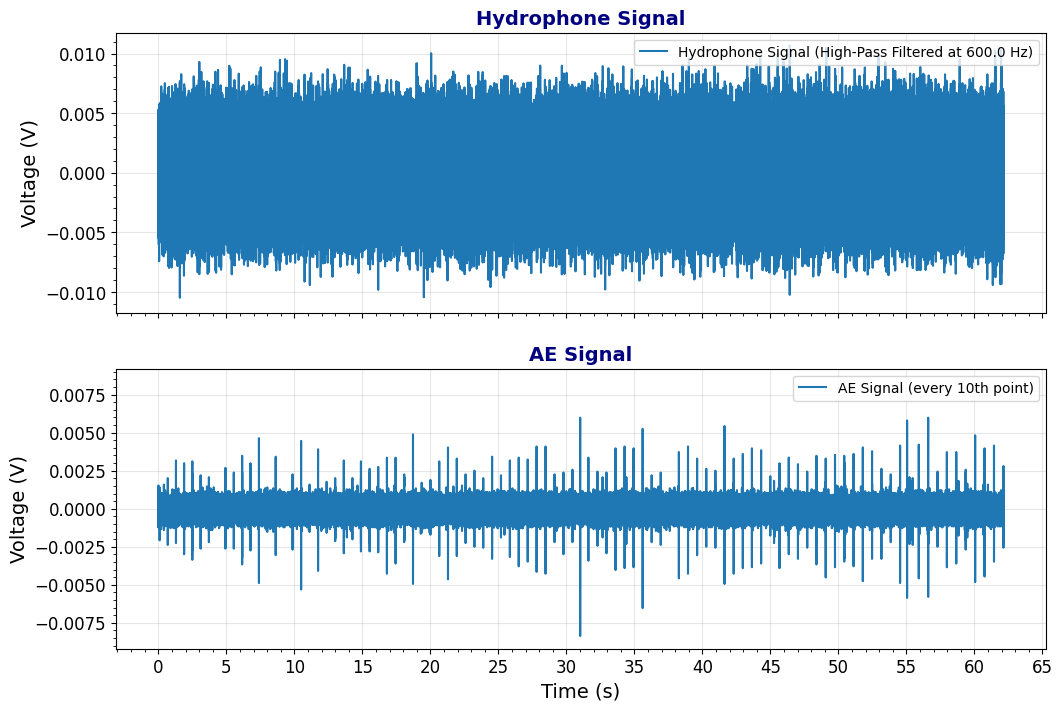

In [11]:
trimmed_lvm_data = lvm_data  # default to untrimmed if not set in the sync block
trimmed_high_pass_lvm_data = high_pass_lvm_data  # default to untrimmed if not set in the sync block
trimmed_ae_data = ae_data  # default to untrimmed if not set in the sync block

# Get the start time and end time of the hydrophone data
start_time_hydrophone = lvm_data[0, 0]
end_time_hydrophone = lvm_data[-1, 0]
print(f"Hydrophone data time range: {start_time_hydrophone:.6f} s to {end_time_hydrophone:.6f} s")

# Get the start time and end time of the AE data
start_time_ae = ae_data[0, 0]
end_time_ae = ae_data[-1, 0]
print(f"AE data time range: {start_time_ae:.6f} s to {end_time_ae:.6f} s")

if start_time_ae > end_time_hydrophone or end_time_ae < start_time_hydrophone:
    raise ValueError("Warning: AE data does not overlap with hydrophone data.")

if sync_data and not data_trimmed:
    # If the AE data starts after the hydrophone data, trim the hydrophone data to start at the AE start time.
    if start_time_ae > start_time_hydrophone:
        trimmed_lvm_data = lvm_data[lvm_data[:, 0] >= start_time_ae]
        trimmed_high_pass_lvm_data = high_pass_lvm_data[high_pass_lvm_data[:, 0] >= start_time_ae]

    # If the hydrophone data starts after the AE data, trim the AE data to start at the hydrophone start time.
    elif start_time_hydrophone > start_time_ae:
        trimmed_ae_data = ae_data[ae_data[:, 0] >= start_time_hydrophone]

    # If the AE data ends before the hydrophone data, trim the hydrophone data to end at the AE end time.
    if end_time_ae < end_time_hydrophone:
        trimmed_lvm_data = lvm_data[lvm_data[:, 0] <= end_time_ae]
        trimmed_high_pass_lvm_data = high_pass_lvm_data[high_pass_lvm_data[:, 0] <= end_time_ae]

    # If the hydrophone data ends before the AE data, trim the AE data to end at the hydrophone end time.
    elif end_time_hydrophone < end_time_ae:
        trimmed_ae_data = ae_data[ae_data[:, 0] <= end_time_hydrophone]
    
    data_trimmed = True

# Plot trimmed data
plot_signals(trimmed_high_pass_lvm_data, trimmed_ae_data, lvm_label=f"Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)", ae_step=10, legend_loc="upper right")
plt.show()

## Optional: Automatically Attempt to Remove Synchronization Peak

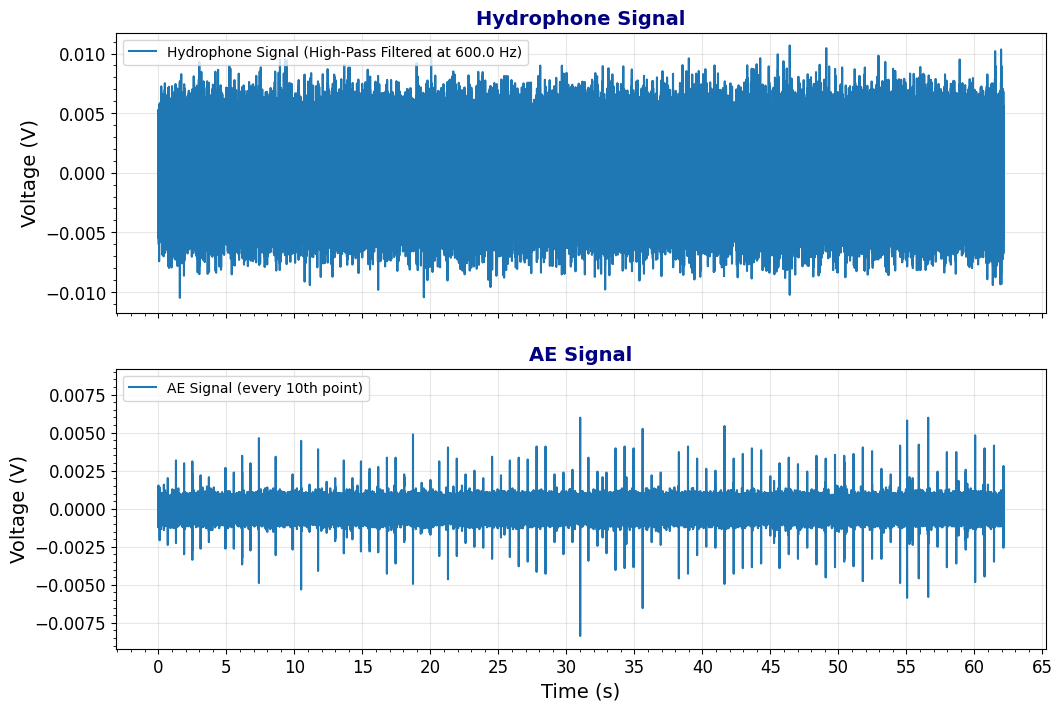

In [12]:
if sync_data:
    # Ask user if they want to automatically detect and mask out initial synchronization peaks
    while True:
        mask_peaks = input("Do you want to automatically detect and mask out " \
                                "the initial synchronization peak? (y/n): ").strip().lower()
        if mask_peaks in ['y', 'n']:
            break

    if mask_peaks == 'y':
        # Find hydrophone peaks above the threshold
        hydrophone_indices = np.where(np.abs(trimmed_lvm_data[:, 1]) > hydrophone_threshold)[0]
        if len(hydrophone_indices) == 0:
            print(f"No hydrophone peaks found above {hydrophone_threshold} V. Cannot set mask.")
        else:
            first_hydrophone_peak_index = hydrophone_indices[0]
            first_hydrophone_peak_time = trimmed_lvm_data[first_hydrophone_peak_index, 0]

            post_peak_buffer = 0.1  # seconds to snip after the peak
            post_peak_cutoff = first_hydrophone_peak_time + post_peak_buffer

            # cut off the front of the hydrophone and AE data to remove the synchronization peak 
            # and any immediate post-peak artifacts
            trimmed_lvm_data = trimmed_lvm_data[trimmed_lvm_data[:, 0] >= post_peak_cutoff]
            trimmed_high_pass_lvm_data = trimmed_high_pass_lvm_data[trimmed_high_pass_lvm_data[:, 0] >= post_peak_cutoff]
            trimmed_ae_data = trimmed_ae_data[trimmed_ae_data[:, 0] >= post_peak_cutoff]

# Plot trimmed data
plot_signals(trimmed_high_pass_lvm_data, trimmed_ae_data, lvm_label=f"Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)", ae_step=10, legend_loc="upper left")
plt.show()

# Generate and Save Figures

## Optional: Manually Trim Time Range Plotted

In [13]:
# Times (s) over which to mask out the x-axis in later plots
start_time_mask = None
end_time_mask = None

# Save bounds of the current auto-trimmed data
start_trimmed_lvm_data = trimmed_lvm_data[0, 0]
end_trimmed_lvm_data = trimmed_lvm_data[-1, 0]

start_trimmed_high_pass_lvm_data = trimmed_high_pass_lvm_data[0, 0]
end_trimmed_high_pass_lvm_data = trimmed_high_pass_lvm_data[-1, 0]

start_trimmed_ae_data = trimmed_ae_data[0, 0]
end_trimmed_ae_data = trimmed_ae_data[-1, 0]

# Fall back to auto-trimmed bounds when manual bounds are None
lvm_start = start_time_mask if start_time_mask is not None else start_trimmed_lvm_data
lvm_end = end_time_mask if end_time_mask is not None else end_trimmed_lvm_data

high_pass_lvm_start = start_time_mask if start_time_mask is not None else start_trimmed_high_pass_lvm_data
high_pass_lvm_end = end_time_mask if end_time_mask is not None else end_trimmed_high_pass_lvm_data

ae_start = start_time_mask if start_time_mask is not None else start_trimmed_ae_data
ae_end = end_time_mask if end_time_mask is not None else end_trimmed_ae_data

# Re-trim from raw data, but preserve the auto-trimmed range where no manual mask is given
trimmed_lvm_data = lvm_data[
    (lvm_data[:, 0] >= lvm_start) &
    (lvm_data[:, 0] <= lvm_end)
]

trimmed_high_pass_lvm_data = high_pass_lvm_data[
    (high_pass_lvm_data[:, 0] >= high_pass_lvm_start) &
    (high_pass_lvm_data[:, 0] <= high_pass_lvm_end)
]

trimmed_ae_data = ae_data[
    (ae_data[:, 0] >= ae_start) &
    (ae_data[:, 0] <= ae_end)
]


def _filename_value(value):
    return f"{float(value):.6g}"


def time_bounds_suffix(*arrays):
    starts = [arr[0, 0] for arr in arrays if arr is not None and len(arr) > 0]
    ends = [arr[-1, 0] for arr in arrays if arr is not None and len(arr) > 0]
    if not starts or not ends:
        return "startNA_endNA"
    return f"start{_filename_value(min(starts))}s_end{_filename_value(max(ends))}s"


def cutoff_suffix():
    return f"hp{_filename_value(cutoff_freq)}Hz"


def ae_spectrogram_suffix():
    return (
        f"aeMaxFreq{_filename_value(max_freq_ae_spec)}Hz"
        f"_aeMin{_filename_value(min_ae_spectrogram_value_ctrl)}"
        f"_aeMax{_filename_value(max_ae_spectrogram_value_ctrl)}"
    )


def hydro_spectrogram_suffix():
    return (
        f"hydroMaxFreq{_filename_value(max_freq_hydro_spec)}Hz"
        f"_hydroMin{_filename_value(min_hydro_spectrogram_value_ctrl)}"
        f"_hydroMax{_filename_value(max_hydro_spectrogram_value_ctrl)}"
    )


def figure_suffix(base, *arrays, include_cutoff=False, include_ae_spec=False, include_hydro_spec=False):
    parts = [base, time_bounds_suffix(*arrays)]
    if include_cutoff:
        parts.append(cutoff_suffix())
    if include_ae_spec:
        parts.append(ae_spectrogram_suffix())
    if include_hydro_spec:
        parts.append(hydro_spectrogram_suffix())
    return "_".join(parts)

## Plot Signal Line Graphs

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\ae_only\PD-acoustic-EMPIRE_12_AE_Signal_start0s_end62.1619s.png


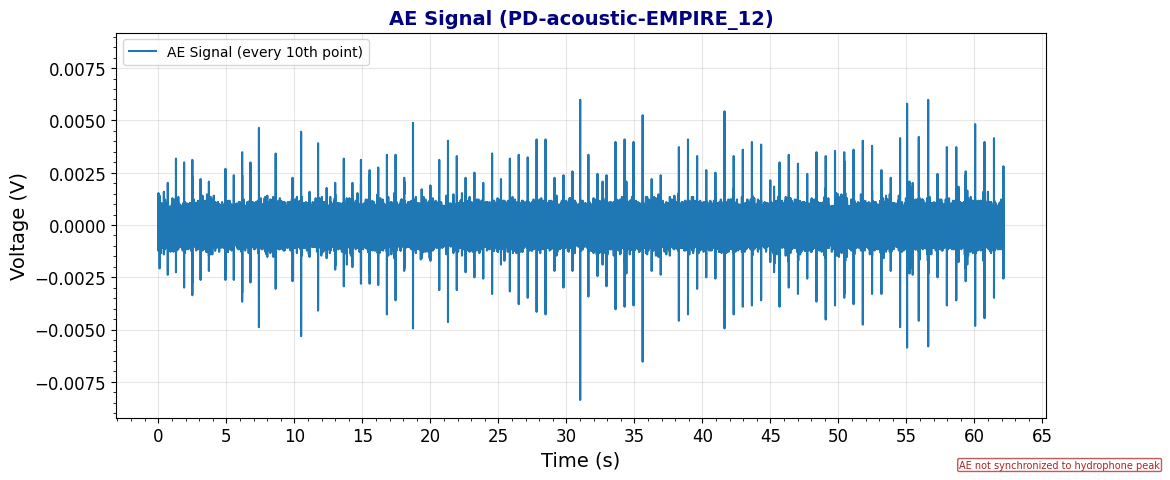

In [14]:
# Plot just AE
ae_step = 10  # plot every nth point to reduce computation (set to 1 to plot all points)
x_ds = trimmed_ae_data[::ae_step, 0]
y_ds = trimmed_ae_data[::ae_step, 1]

if ae_step == 1:
    ae_label = "AE Signal"
else:
    if ae_step % 100 in (11, 12, 13):  # Special case for 11th, 12th, 13th
        suffix = "th"
    elif ae_step % 10 == 1:
        suffix = "st"
    elif ae_step % 10 == 2:
        suffix = "nd"
    elif ae_step % 10 == 3:
        suffix = "rd"
    else:
        suffix = "th"
        
    ae_label = f"AE Signal (every {ae_step}{suffix} point)"

y_padding = 1.1

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(x_ds, y_ds, label=ae_label)
ae_abs_max = np.max(np.abs(y_ds))
ax1.set_ylim(-ae_abs_max * y_padding, ae_abs_max * y_padding)
ax1.set_xlabel("Time (s)", fontsize=label_size)
ax1.set_ylabel("Voltage (V)", fontsize=label_size)
ax1.set_title(f"AE Signal ({lvm_stem})", fontsize=label_size, fontweight='bold', color='navy')
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis='both', which='major', labelsize=tick_size)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

save_figure(fig, figure_suffix("AE_Signal", trimmed_ae_data), category="ae_only", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Unfiltered_Hydrophone_Signal_start0s_end62.1619s.png


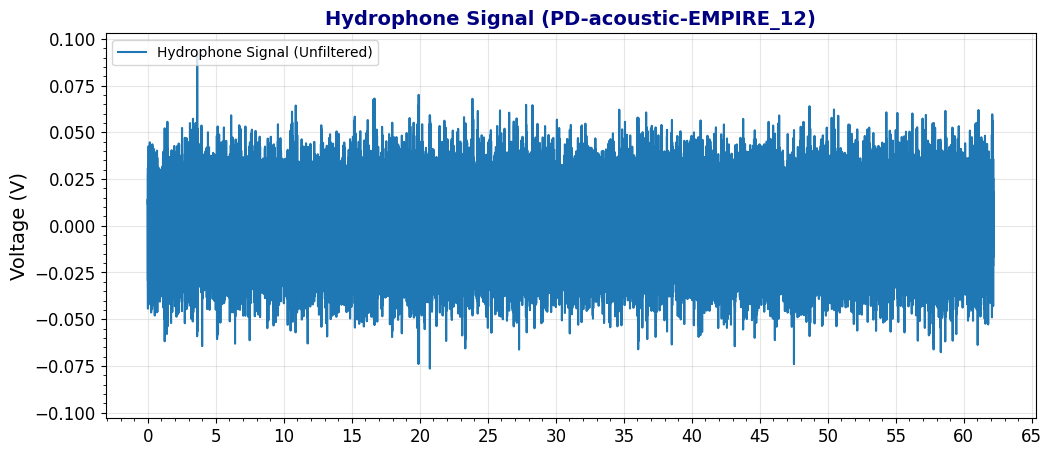

In [15]:
y_padding = 1.1

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(trimmed_lvm_data[:, 0], trimmed_lvm_data[:, 1], label="Hydrophone Signal (Unfiltered)")
lvm_abs_max = np.max(np.abs(trimmed_lvm_data[:, 1]))
ax1.set_ylim(-lvm_abs_max * y_padding, lvm_abs_max * y_padding)
ax1.set_ylabel('Voltage (V)', fontsize=label_size)
ax1.set_title(f"Hydrophone Signal ({lvm_stem})", fontsize=label_size, fontweight='bold', color='navy')
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis='both', which='major', labelsize=tick_size)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

save_figure(fig, figure_suffix("Unfiltered_Hydrophone_Signal", trimmed_lvm_data), category="hydrophone_only", dpi=figure_dpi)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Filtered_Hydrophone_Signal_start0s_end62.1619s_hp600Hz.png


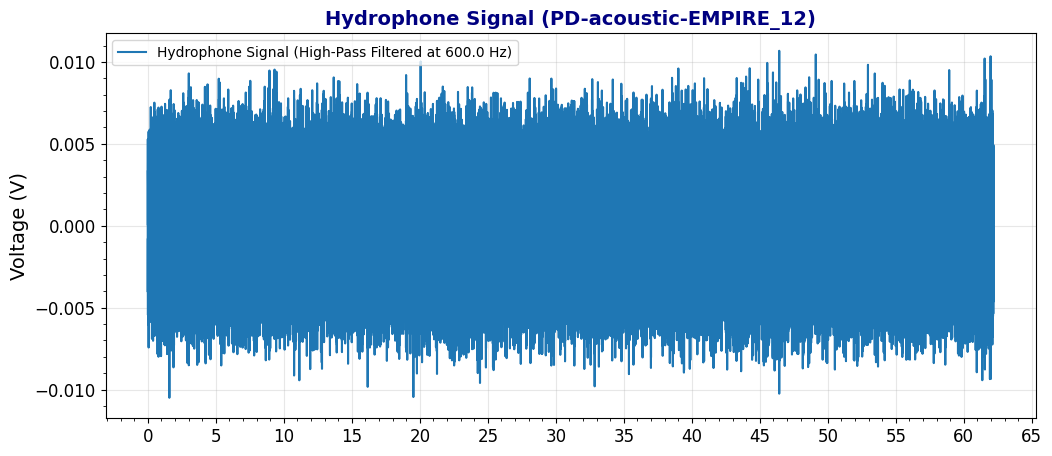

In [16]:
y_padding = 1.1

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(trimmed_high_pass_lvm_data[:, 0], trimmed_high_pass_lvm_data[:, 1], label=f"Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)")
lvm_abs_max = np.max(np.abs(trimmed_high_pass_lvm_data[:, 1]))
ax1.set_ylim(-lvm_abs_max * y_padding, lvm_abs_max * y_padding)
ax1.set_ylabel('Voltage (V)', fontsize=label_size)
ax1.set_title(f"Hydrophone Signal ({lvm_stem})", fontsize=label_size, fontweight='bold', color='navy')
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis='both', which='major', labelsize=tick_size)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

save_figure(fig, figure_suffix("Filtered_Hydrophone_Signal", trimmed_high_pass_lvm_data, include_cutoff=True), category="hydrophone_only", dpi=figure_dpi)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_AE_and_Unfiltered_Hydrophone_Signal_start0s_end62.1619s.png


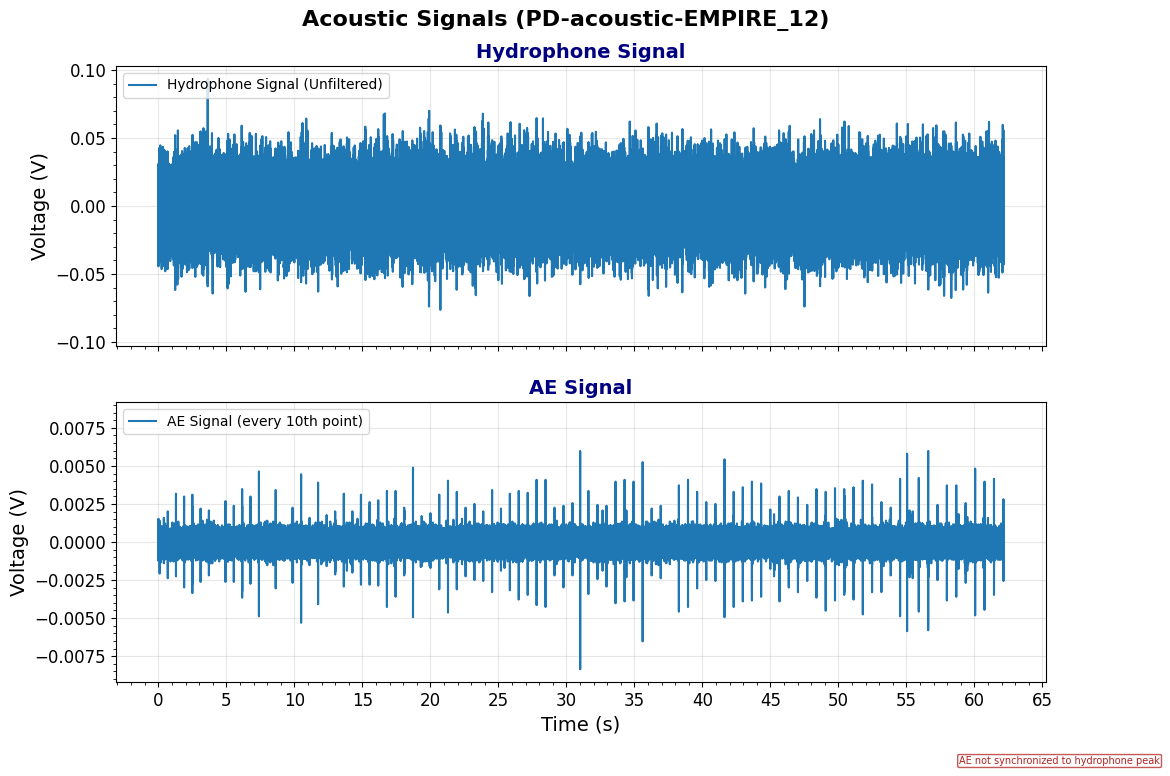

In [17]:
# Plot AE and unfiltered hydrophone data
fig, _ = plot_signals(trimmed_lvm_data, trimmed_ae_data, lvm_label="Hydrophone Signal (Unfiltered)", ae_step=10, sup_title=f"Acoustic Signals ({lvm_stem})", legend_loc="upper left")
save_figure(fig, figure_suffix("AE_and_Unfiltered_Hydrophone_Signal", trimmed_lvm_data, trimmed_ae_data), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_AE_and_Filtered_Hydrophone_Signal_start0s_end62.1619s_hp600Hz.png


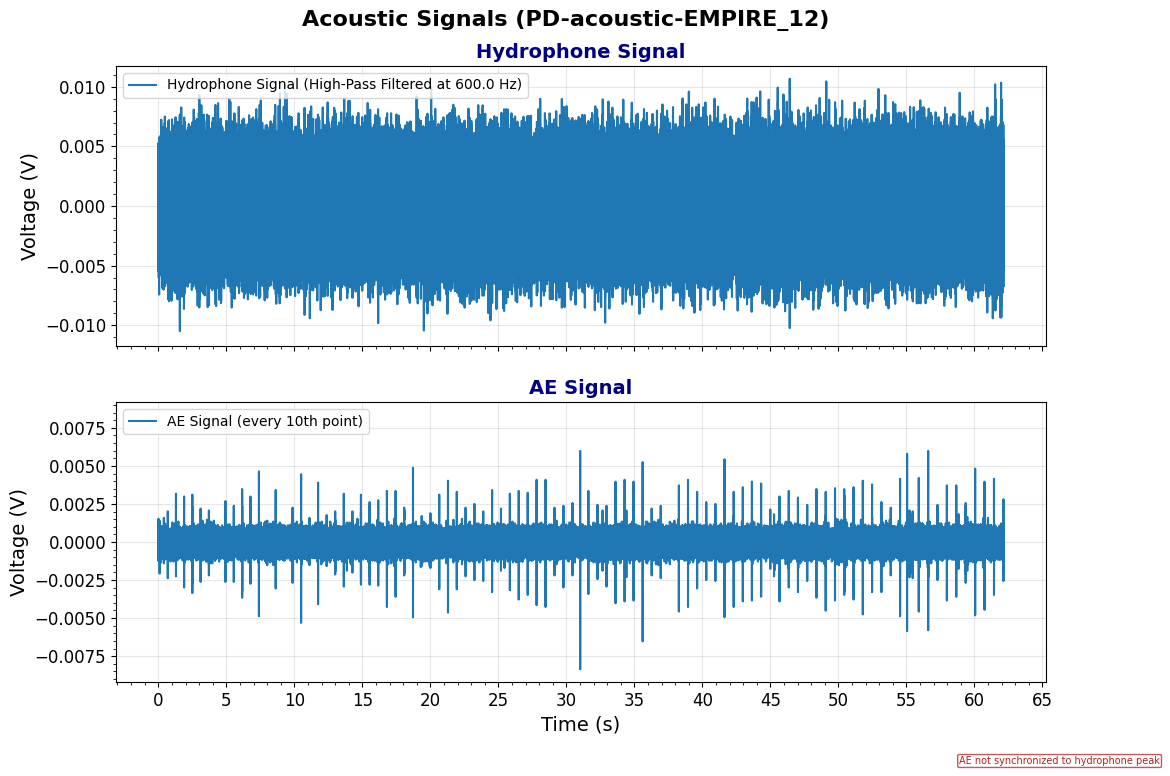

In [18]:
# Plot AE and filtered hydrophone data
fig, _ = plot_signals(trimmed_high_pass_lvm_data, trimmed_ae_data, lvm_label=f"Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)", ae_step=10, sup_title=f"Acoustic Signals ({lvm_stem})")
save_figure(fig, figure_suffix("AE_and_Filtered_Hydrophone_Signal", trimmed_high_pass_lvm_data, trimmed_ae_data, include_cutoff=True), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()

## Calculate Hydrophone RMS Amplitude

In [19]:
# RMS Amplitude over windowed time segments (vectorised)
hydrophone_window_duration = 0.01  # Window size in seconds

hydrophone_time = trimmed_lvm_data[:, 0]
hydrophone_signal = trimmed_lvm_data[:, 1]
hydrophone_time_hp = trimmed_high_pass_lvm_data[:, 0]
hydrophone_signal_hp = trimmed_high_pass_lvm_data[:, 1]

# Infer sample rate from data and derive samples per window
dt = np.mean(np.diff(hydrophone_time[:1000]))          # Use first 1000 diffs for speed
sample_rate = 1.0 / dt
samples_per_window = max(1, int(round(hydrophone_window_duration * sample_rate)))

# Truncate signal so it divides evenly into windows
n_windows = len(hydrophone_signal) // samples_per_window
signal_trimmed = hydrophone_signal[:n_windows * samples_per_window]
time_trimmed   = hydrophone_time[:n_windows * samples_per_window]
signal_hp_trimmed = hydrophone_signal_hp[:n_windows * samples_per_window]
time_hp_trimmed   = hydrophone_time_hp[:n_windows * samples_per_window]

# Reshape → (n_windows, samples_per_window), then RMS along axis=1
windows    = signal_trimmed.reshape(n_windows, samples_per_window)
hydrophone_rms_values = np.sqrt(np.mean(windows ** 2, axis=1))
hp_windows = signal_hp_trimmed.reshape(n_windows, samples_per_window)
hydrophone_rms_values_hp = np.sqrt(np.mean(hp_windows ** 2, axis=1))

# Use the midpoint of each window as its time label
hydrophone_rms_times  = time_trimmed.reshape(n_windows, samples_per_window)[:, samples_per_window // 2]
hydrophone_rms_times_hp  = time_hp_trimmed.reshape(n_windows, samples_per_window)[:, samples_per_window // 2]

## Plot Hydrophone RMS Amplitude

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Unfiltered_Hydrophone_RMS_Amplitude_start0s_end62.1619s.png


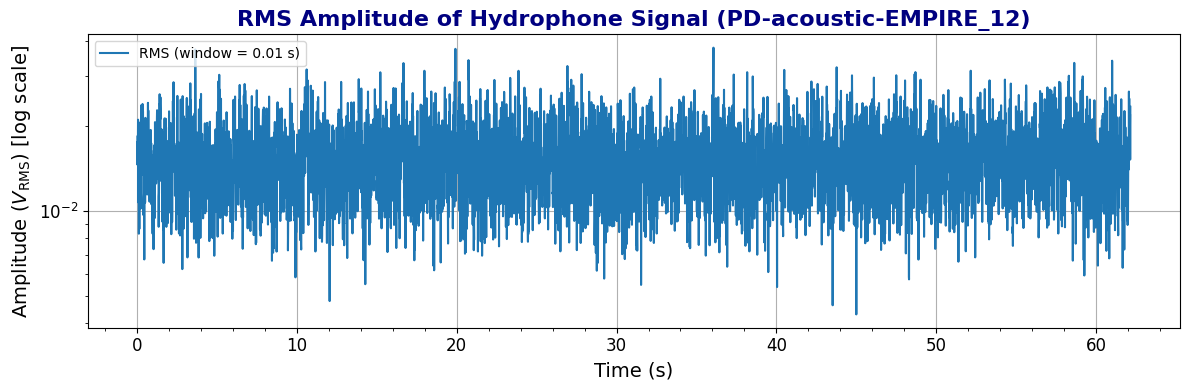

In [20]:
plot_log_scale = True  # Set to True to use logarithmic scale for RMS plot

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hydrophone_rms_times, hydrophone_rms_values, label=f"RMS (window = {hydrophone_window_duration} s)")
ax.set_xlabel("Time (s)", fontsize=label_size)
if plot_log_scale:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax.set_yscale("log")
else:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax.set_title(f"RMS Amplitude of Hydrophone Signal ({lvm_stem})", fontsize=16, fontweight='bold', color='navy')
ax.grid(True)
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, steps=[1, 2, 2.5, 5, 10]))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='major', labelsize=tick_size)
fig.tight_layout()

save_figure(fig, figure_suffix("Unfiltered_Hydrophone_RMS_Amplitude", trimmed_lvm_data), category="hydrophone_only", dpi=figure_dpi)
plt.show()

## Plot Filtered Hydrophone RMS Amplitude

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Filtered_Hydrophone_RMS_Amplitude_start0s_end62.1619s_hp600Hz.png


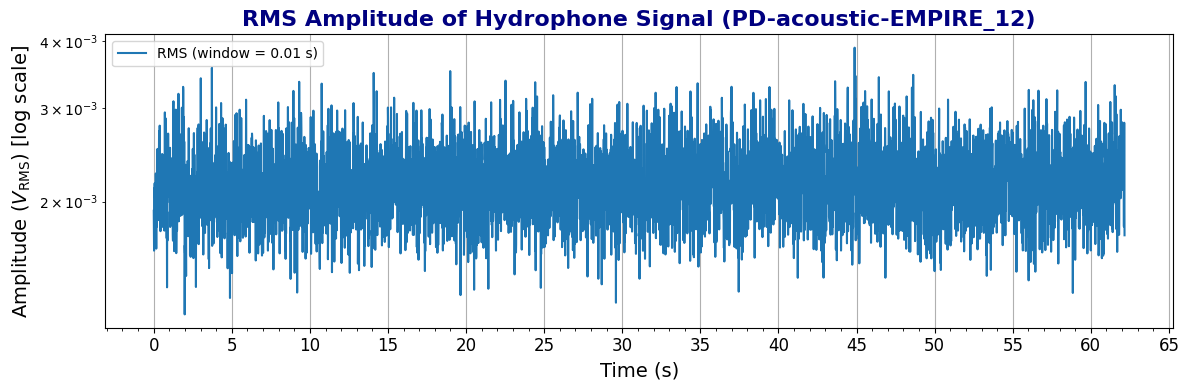

In [21]:
plot_log_scale = True  # Set to True to use logarithmic scale for RMS plot

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hydrophone_rms_times_hp, hydrophone_rms_values_hp, label=f"RMS (window = {hydrophone_window_duration} s)")
ax.set_xlabel("Time (s)", fontsize=label_size)
if plot_log_scale:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax.set_yscale("log")
else:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax.set_title(f"RMS Amplitude of Hydrophone Signal ({lvm_stem})", fontsize=16, fontweight='bold', color='navy')
ax.grid(True)
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='major', labelsize=tick_size)
fig.tight_layout()

save_figure(fig, figure_suffix("Filtered_Hydrophone_RMS_Amplitude", trimmed_high_pass_lvm_data, include_cutoff=True), category="hydrophone_only", dpi=figure_dpi)
plt.show()

## Calculate AE RMS Amplitude

In [22]:
# RMS Amplitude over windowed time segments (vectorised)
ae_window_duration = 0.01  # Window size in seconds

ae_time = trimmed_ae_data[:, 0]
ae_signal = trimmed_ae_data[:, 1]

# Infer sample rate from data and derive samples per window
dt = np.mean(np.diff(ae_time[:1000]))          # Use first 1000 diffs for speed
sample_rate = 1.0 / dt
samples_per_window = max(1, int(round(ae_window_duration * sample_rate)))

# Truncate signal so it divides evenly into windows
n_windows = len(ae_signal) // samples_per_window
signal_trimmed = ae_signal[:n_windows * samples_per_window]
time_trimmed   = ae_time[:n_windows * samples_per_window]

# Reshape → (n_windows, samples_per_window), then RMS along axis=1
windows    = signal_trimmed.reshape(n_windows, samples_per_window)
ae_rms_values = np.sqrt(np.mean(windows ** 2, axis=1))

# Use the midpoint of each window as its time label
ae_rms_times  = time_trimmed.reshape(n_windows, samples_per_window)[:, samples_per_window // 2]

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\ae_only\PD-acoustic-EMPIRE_12_AE_RMS_Amplitude_start0s_end62.1619s.png


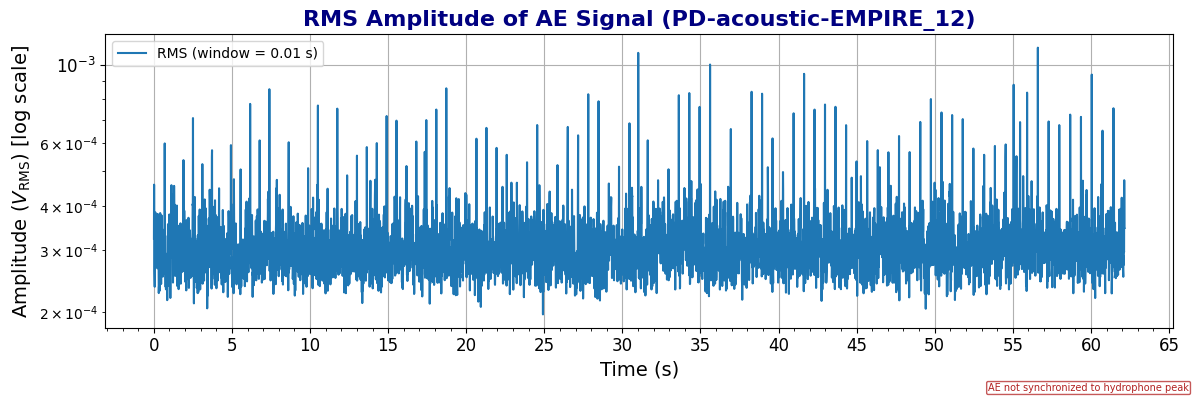

In [23]:
plot_log_scale = True  # Set to True to use logarithmic scale for RMS plot

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ae_rms_times, ae_rms_values, label=f"RMS (window = {ae_window_duration} s)")
ax.set_xlabel("Time (s)", fontsize=label_size)
if plot_log_scale:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax.set_yscale("log")
else:
    ax.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax.set_title(f"RMS Amplitude of AE Signal ({lvm_stem})", fontsize=16, fontweight='bold', color='navy')
ax.grid(True)
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(axis='both', which='major', labelsize=tick_size)
fig.tight_layout()

save_figure(fig, figure_suffix("AE_RMS_Amplitude", trimmed_ae_data), category="ae_only", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_Hydrophone_Unfiltered_AE_RMS_Amplitude_start0s_end62.1619s.png


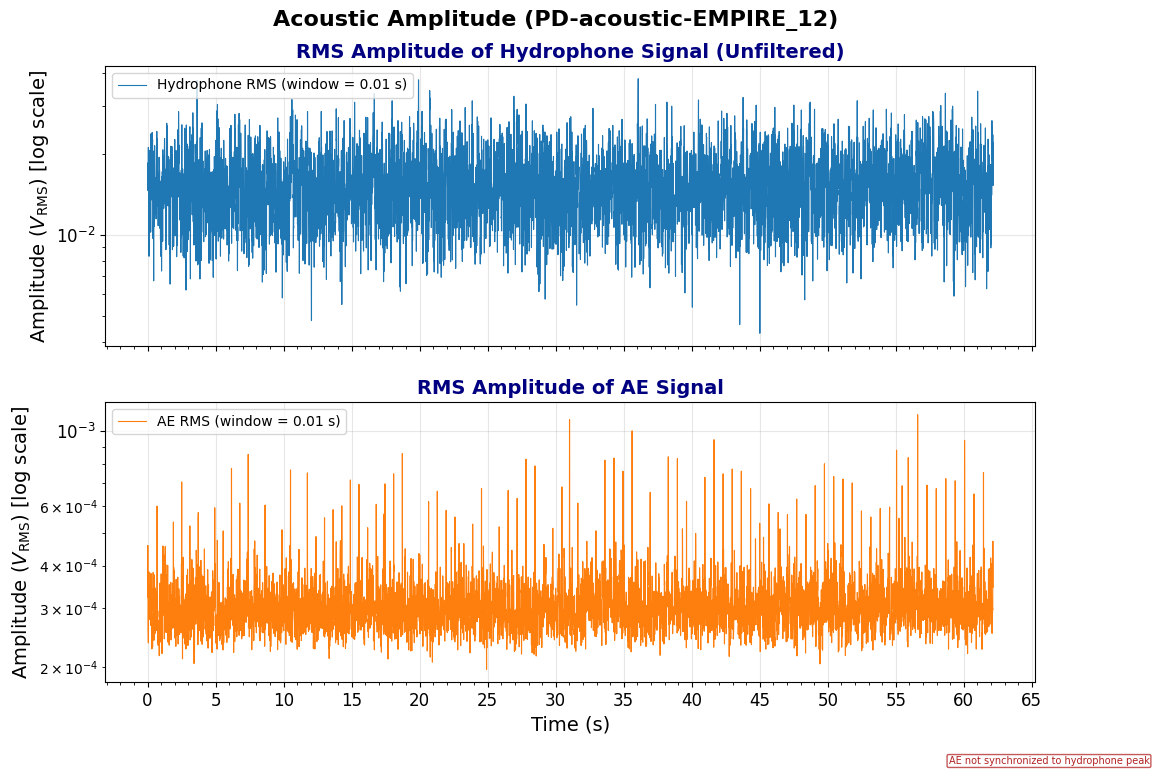

In [24]:
plot_log_scale = True  # Set to True to use logarithmic scale for RMS plots

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Hydrophone Amplitude (Unfiltered) ---
ax1.plot(
    hydrophone_rms_times,
    hydrophone_rms_values,
    color="tab:blue",
    linewidth=0.8,
    label=f"Hydrophone RMS (window = {hydrophone_window_duration} s)"
)
ax1.set_title("RMS Amplitude of Hydrophone Signal (Unfiltered)", fontsize=label_size, fontweight="bold", color='navy')
if plot_log_scale:
    ax1.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax1.set_yscale("log")
else:
    ax1.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis="both", which="major", labelsize=tick_size)

# --- AE Amplitude ---
ax2.plot(
    ae_rms_times,
    ae_rms_values,
    color="tab:orange",
    linewidth=0.8,
    label=f"AE RMS (window = {ae_window_duration} s)"
)
ax2.set_xlabel("Time (s)", fontsize=label_size)
ax2.set_title("RMS Amplitude of AE Signal", fontsize=label_size, fontweight="bold", color='navy')
if plot_log_scale:
    ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax2.set_yscale("log")
else:
    ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left")
ax2.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(axis="both", which="major", labelsize=tick_size)

fig.suptitle(
    f"Acoustic Amplitude ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.95
)

# fig.tight_layout()

save_figure(fig, figure_suffix("Hydrophone_Unfiltered_AE_RMS_Amplitude", trimmed_lvm_data, trimmed_ae_data), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()


Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_Hydrophone_High_Pass_Filtered_AE_RMS_Amplitude_start0s_end62.1619s_hp600Hz.png


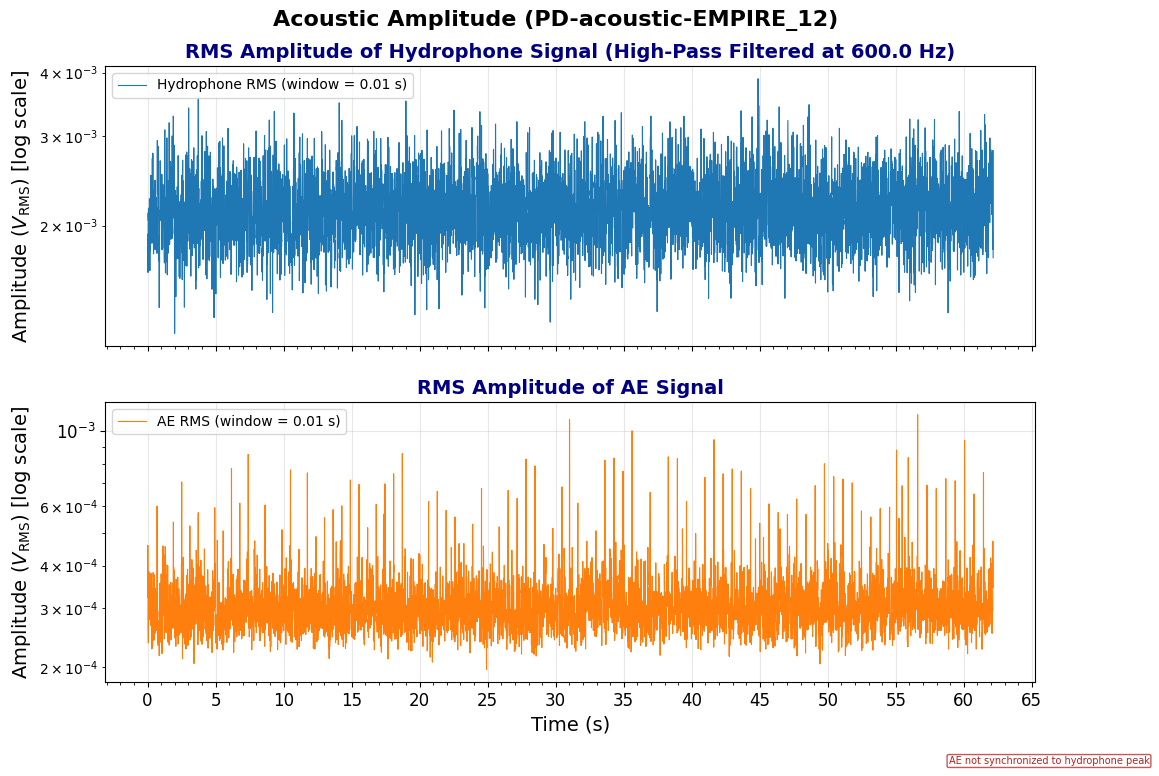

In [25]:
plot_log_scale = True  # Set to True to use logarithmic scale for RMS plots

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Hydrophone Amplitude (High-Pass Filtered) ---
ax1.plot(
    hydrophone_rms_times_hp,
    hydrophone_rms_values_hp,
    color="tab:blue",
    linewidth=0.8,
    label=f"Hydrophone RMS (window = {hydrophone_window_duration} s)"
)
ax1.set_title(f"RMS Amplitude of Hydrophone Signal (High-Pass Filtered at {cutoff_freq} Hz)", fontsize=label_size, fontweight="bold", color='navy')
if plot_log_scale:
    ax1.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax1.set_yscale("log")
else:
    ax1.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis="both", which="major", labelsize=tick_size)

# --- AE Amplitude ---
ax2.plot(
    ae_rms_times,
    ae_rms_values,
    color="tab:orange",
    linewidth=0.8,
    label=f"AE RMS (window = {ae_window_duration} s)"
)
ax2.set_xlabel("Time (s)", fontsize=label_size)
ax2.set_title("RMS Amplitude of AE Signal", fontsize=label_size, fontweight="bold", color='navy')
if plot_log_scale:
    ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$) [log scale]", fontsize=label_size)
    ax2.set_yscale("log")
else:
    ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left")
ax2.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(axis="both", which="major", labelsize=tick_size)

fig.suptitle(
    f"Acoustic Amplitude ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.95
)

# fig.tight_layout()

hp_ae_amplitude_comparative_path = save_figure(fig, figure_suffix("Hydrophone_High_Pass_Filtered_AE_RMS_Amplitude", trimmed_high_pass_lvm_data, trimmed_ae_data, include_cutoff=True), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()

## Define Spectrogram Utilities

In [26]:
# Define helper functions for batched Welch and spectrogram calculations that can handle very 
# long AE streams without running out of memory.

def _as_float64_1d(values):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 1:
        values = np.ravel(values)
    return values


def _double_onesided_power(power, nperseg):
    if nperseg % 2 == 0:
        if power.shape[-1] > 2:
            power[..., 1:-1] *= 2.0
    elif power.shape[-1] > 1:
        power[..., 1:] *= 2.0
    return power


def welch_batched(signal, fs, nperseg=4096, noverlap=None, max_segments_per_batch=1024):
    """Welch PSD with bounded memory for very long 1-D AE streams."""
    signal = _as_float64_1d(signal)
    n_samples = signal.size
    if n_samples == 0:
        raise ValueError('AE signal is empty.')

    nperseg = int(max(8, min(nperseg, n_samples)))
    if noverlap is None:
        noverlap = nperseg // 2
    noverlap = int(max(0, min(noverlap, nperseg - 1)))
    hop = nperseg - noverlap
    n_segments = 1 + max(0, (n_samples - nperseg) // hop)

    win = get_window('hann', nperseg).astype(np.float64, copy=False)
    scale = 1.0 / (float(fs) * np.sum(win ** 2))
    freqs = np.fft.rfftfreq(nperseg, d=1.0 / float(fs))
    psd_sum = np.zeros(freqs.shape, dtype=np.float64)

    sample_stride = signal.strides[0]
    segments = as_strided(
        signal,
        shape=(n_segments, nperseg),
        strides=(hop * sample_stride, sample_stride),
        writeable=False,
    )

    for start in range(0, n_segments, max_segments_per_batch):
        stop = min(start + max_segments_per_batch, n_segments)
        batch = segments[start:stop]
        batch = batch - np.mean(batch, axis=1, keepdims=True)
        ffts = np.fft.rfft(batch * win[np.newaxis, :], axis=1)
        power = (np.abs(ffts) ** 2) * scale
        power = _double_onesided_power(power, nperseg)
        psd_sum += np.sum(power, axis=0)

    return freqs, psd_sum / n_segments, n_segments, hop, nperseg


def spectrogram_strided_batched(signal, fs, nperseg=4096, n_time_bins=2400, max_segments_per_batch=512):
    """Display-oriented spectrogram capped to roughly n_time_bins columns."""
    signal = _as_float64_1d(signal)
    n_samples = signal.size
    if n_samples == 0:
        raise ValueError('AE signal is empty.')

    n_time_bins = int(max(1, n_time_bins))
    step = max(1, n_samples // n_time_bins)
    nperseg = int(max(8, min(nperseg, n_samples)))
    n_segments = 1 + max(0, (n_samples - nperseg) // step)

    win = get_window('hann', nperseg).astype(np.float64, copy=False)
    scale = 1.0 / (float(fs) * np.sum(win ** 2))
    freqs = np.fft.rfftfreq(nperseg, d=1.0 / float(fs))
    sxx = np.empty((freqs.size, n_segments), dtype=np.float32)

    sample_stride = signal.strides[0]
    segments = as_strided(
        signal,
        shape=(n_segments, nperseg),
        strides=(step * sample_stride, sample_stride),
        writeable=False,
    )

    for start in range(0, n_segments, max_segments_per_batch):
        stop = min(start + max_segments_per_batch, n_segments)
        batch = segments[start:stop]
        batch = batch - np.mean(batch, axis=1, keepdims=True)
        ffts = np.fft.rfft(batch * win[np.newaxis, :], axis=1)
        power = (np.abs(ffts) ** 2) * scale
        power = _double_onesided_power(power, nperseg)
        sxx[:, start:stop] = power.T.astype(np.float32, copy=False)

    times = (np.arange(n_segments, dtype=np.float64) * step + nperseg / 2) / float(fs)
    return freqs, times, sxx, step, nperseg

## Calculate AE Spectrogram

In [27]:
# Compute a display-oriented spectrogram with bounded time bins.

max_freq_ae_spec = 200e3  # Frequency (Hz) over which to mask out the y-axis

nperseg_ae_spec = 4096*4  # Number of samples per segment for AE spectrogram (controls frequency-axis resolution)
ae_spectrogram_time_bins = 4800  # Increase for more time-axis resolution; 
# memory scales with frequency_bins * spectrogram_time_bins.

ae_frequencies, ae_rel_times, ae_Sxx, ae_spectrogram_step, ae_spectrogram_nperseg = spectrogram_strided_batched(
    trimmed_ae_data[:, 1],
    ae_sample_rate,
    nperseg=nperseg_ae_spec,
    n_time_bins=ae_spectrogram_time_bins,
)
ae_Sxx_log = 10 * np.log10(np.maximum(ae_Sxx, np.finfo(np.float32).tiny))

print(
    f"Strided AE spectrogram shape: {ae_Sxx_log.shape}, "
    f"step={ae_spectrogram_step:,} samples, nperseg={ae_spectrogram_nperseg:,}"
)

ae_sync_times = ae_rel_times + trimmed_ae_data[0, 0]
print(f"AE relative time range: {ae_rel_times[0]:.6f} s to {ae_rel_times[-1]:.6f} s")
print(f"AE absolute time range: {ae_sync_times[0]:.6f} s to {ae_sync_times[-1]:.6f} s")

freq_mask = ae_frequencies <= max_freq_ae_spec
ae_masked_frequencies = ae_frequencies[freq_mask]
ae_masked_Sxx_log = ae_Sxx_log[freq_mask, :]
print(f"Masked AE Sxx_log shape: {ae_masked_Sxx_log.shape}")

Strided AE spectrogram shape: (8193, 4799), step=12,950 samples, nperseg=16,384
AE relative time range: 0.008192 s to 62.142292 s
AE absolute time range: 0.008192 s to 62.142292 s
Masked AE Sxx_log shape: (3277, 4799)


## Calculate Hydrophone Spectrogram

In [28]:
# --- Calculate spectrogram for the unfiltered hydrophone signal ---
max_freq_hydro_spec = 12e3  # Frequency (Hz) over which to mask out the y-axis
nperseg_hydro_spec = 1024  # Number of samples per segment for hydrophone spectrogram
noverlap_hydro_spec = nperseg_hydro_spec // 2  # Number of overlapping samples for hydrophone spectrogram

hydrophone_frequencies, hydrophone_rel_times, hydrophone_Sxx = spectrogram(
    trimmed_lvm_data[:, 1],
    hydrophone_sample_rate,
    scaling='spectrum',
    nperseg=nperseg_hydro_spec,
    noverlap=noverlap_hydro_spec,
)
hydrophone_Sxx_log = 10 * np.log10(np.maximum(hydrophone_Sxx, np.finfo(np.float32).tiny))

hydrophone_sync_times = hydrophone_rel_times + trimmed_lvm_data[0, 0]
print(f"Hydrophone relative time range: {hydrophone_rel_times[0]:.6f} s to {hydrophone_rel_times[-1]:.6f} s")
print(f"Hydrophone absolute time range: {hydrophone_sync_times[0]:.6f} s to {hydrophone_sync_times[-1]:.6f} s")

freq_mask = hydrophone_frequencies <= max_freq_hydro_spec
hydrophone_masked_frequencies = hydrophone_frequencies[freq_mask]
hydrophone_masked_Sxx_log = hydrophone_Sxx_log[freq_mask, :]
print(f"Masked Hydrophone Sxx_log shape: {hydrophone_masked_Sxx_log.shape}")



# --- Calculate spectrogram for the high-pass filtered hydrophone signal ---
hydrophone_hp_frequencies, hydrophone_hp_rel_times, hydrophone_hp_Sxx = spectrogram(
    trimmed_high_pass_lvm_data[:, 1],
    hydrophone_sample_rate,
    scaling='spectrum',
    nperseg=nperseg_hydro_spec,
    noverlap=noverlap_hydro_spec,
)
hydrophone_hp_Sxx_log = 10 * np.log10(np.maximum(hydrophone_hp_Sxx, np.finfo(np.float32).tiny))

hydrophone_hp_sync_times = hydrophone_hp_rel_times + trimmed_high_pass_lvm_data[0, 0]
print(f"Hydrophone HP relative time range: {hydrophone_hp_rel_times[0]:.6f} s to {hydrophone_hp_rel_times[-1]:.6f} s")
print(f"Hydrophone HP absolute time range: {hydrophone_hp_sync_times[0]:.6f} s to {hydrophone_hp_sync_times[-1]:.6f} s")

freq_mask = hydrophone_hp_frequencies <= max_freq_hydro_spec
hydrophone_hp_masked_frequencies = hydrophone_hp_frequencies[freq_mask]
hydrophone_hp_masked_Sxx_log = hydrophone_hp_Sxx_log[freq_mask, :]
print(f"Masked Hydrophone HP Sxx_log shape: {hydrophone_hp_masked_Sxx_log.shape}")

Hydrophone relative time range: 0.040000 s to 62.120000 s
Hydrophone absolute time range: 0.040000 s to 62.120000 s
Masked Hydrophone Sxx_log shape: (513, 1553)
Hydrophone HP relative time range: 0.040000 s to 62.120000 s
Hydrophone HP absolute time range: 0.040000 s to 62.120000 s
Masked Hydrophone HP Sxx_log shape: (513, 1553)


## Plot Spectrograms

### Set AE Spectrogram Parameters

In [29]:
max_ae_spectrogram_value_ctrl = -100
min_ae_spectrogram_value_ctrl = -145
ae_cmap = 'viridis'

### Set Hydrophone Spectrogram Parameters

In [30]:
max_hydro_spectrogram_value_ctrl = -60
min_hydro_spectrogram_value_ctrl = -100
hydro_cmap = 'viridis'

### Generate Hydrophone-Only Plot

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Unfiltered_Hydrophone_Spectrogram_start0s_end62.1619s_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


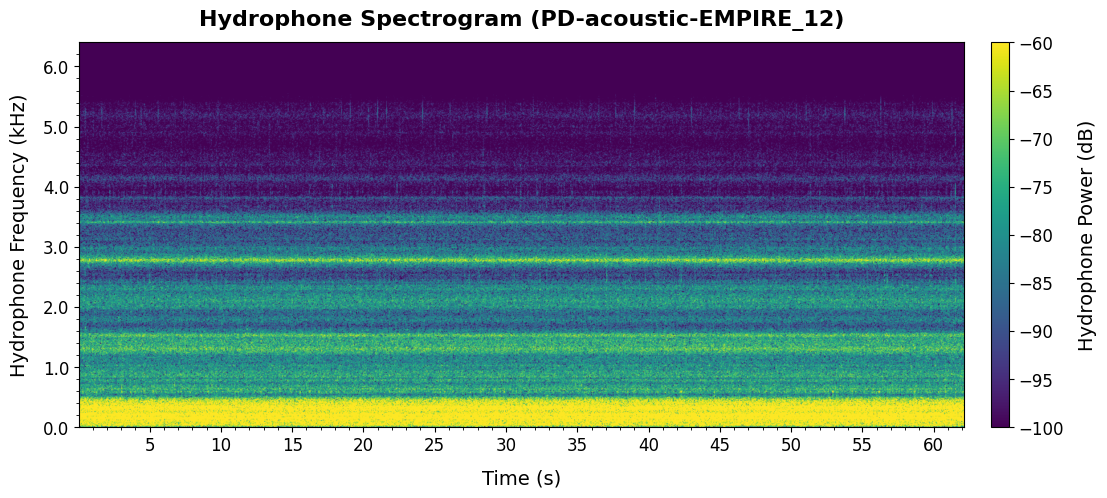

In [31]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1],
    hspace=0.10,                 # Small vertical gap between plots
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Left: Hydrophone spectrogram
cax1 = fig.add_subplot(gs[0, 1])              # Right: Hydrophone colorbar axis (aligned with spectrogram)

# --- Plot Hydrophone Spectrogram ---
im1 = ax1.imshow(
    hydrophone_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_sync_times[0],
        hydrophone_sync_times[-1],
        hydrophone_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax1.set_title(f'Hydrophone Spectrogram ({lvm_stem})', fontsize=16, pad=12, fontweight='bold')
ax1.set_xlabel('Time (s)', fontsize=label_size, labelpad=10)
ax1.set_ylabel('Hydrophone Frequency (kHz)', fontsize=label_size, labelpad=10)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax1.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach hydrophone colorbar to the narrower cax1 axis
cbar = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=tick_size)

save_figure(fig, figure_suffix("Unfiltered_Hydrophone_Spectrogram", trimmed_lvm_data, include_hydro_spec=True), category="hydrophone_only", dpi=figure_dpi)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\hydrophone_only\PD-acoustic-EMPIRE_12_Filtered_Hydrophone_Spectrogram_start0s_end62.1619s_hp600Hz_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


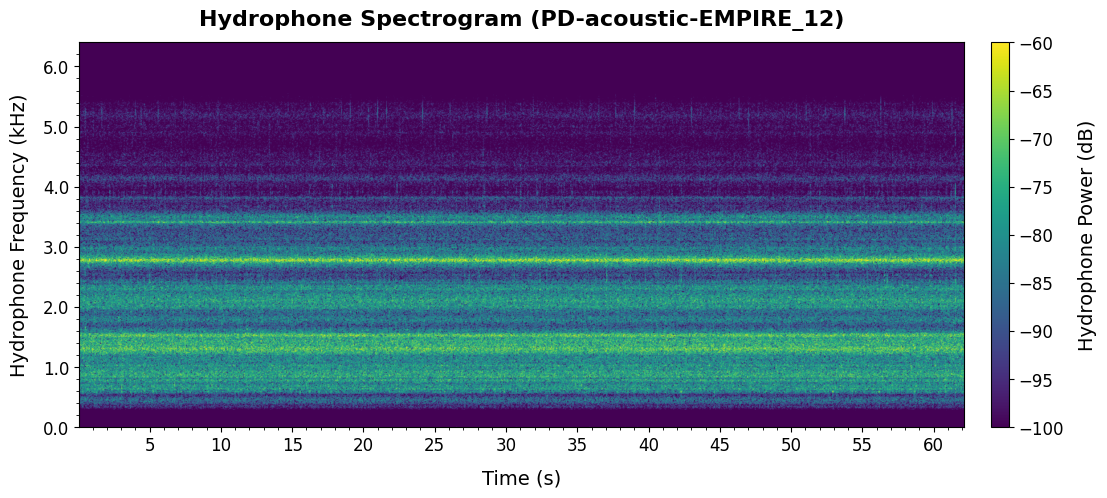

In [32]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1],
    hspace=0.10,                 # Small vertical gap between plots
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Left: Hydrophone spectrogram
cax1 = fig.add_subplot(gs[0, 1])              # Right: Hydrophone colorbar axis (aligned with spectrogram)

# --- Plot Hydrophone Spectrogram ---
im1 = ax1.imshow(
    hydrophone_hp_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_hp_sync_times[0],
        hydrophone_hp_sync_times[-1],
        hydrophone_hp_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_hp_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax1.set_title(f'Hydrophone Spectrogram ({lvm_stem})', fontsize=16, pad=12, fontweight='bold')
ax1.set_xlabel('Time (s)', fontsize=label_size, labelpad=10)
ax1.set_ylabel('Hydrophone Frequency (kHz)', fontsize=label_size, labelpad=10)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax1.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach hydrophone colorbar to the narrower cax1 axis
cbar = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=tick_size)

hp_hydrophone_spectrogram_path = save_figure(fig, figure_suffix("Filtered_Hydrophone_Spectrogram", trimmed_high_pass_lvm_data, include_cutoff=True, include_hydro_spec=True), category="hydrophone_only", dpi=figure_dpi)
plt.show()

### Generate AE-Only Plot

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\ae_only\PD-acoustic-EMPIRE_12_AE_Spectrogram_start0s_end62.1619s_aeMaxFreq200000Hz_aeMin-145_aeMax-100.png


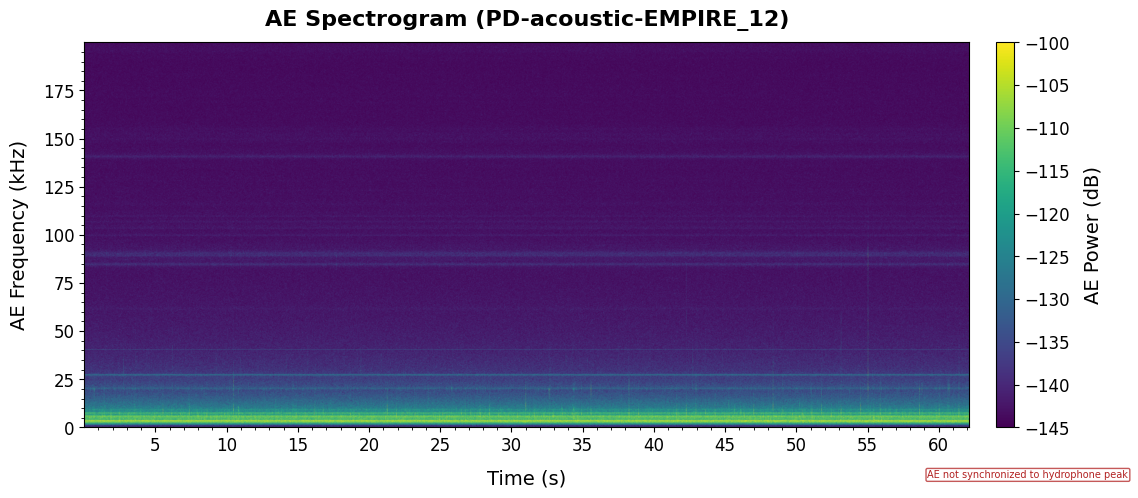

In [33]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1],
    hspace=0.10,                 # Small vertical gap between plots
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Left: AE spectrogram
cax1 = fig.add_subplot(gs[0, 1])              # Right: AE colorbar axis (aligned with spectrogram)

# --- Plot AE Spectrogram ---
im1 = ax1.imshow(
    ae_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        ae_sync_times[0],
        ae_sync_times[-1],
        ae_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        ae_masked_frequencies[-1] / 1e3
    ],
    vmin=min_ae_spectrogram_value_ctrl,
    vmax=max_ae_spectrogram_value_ctrl,
    cmap=ae_cmap,
    interpolation='bilinear'
)
ax1.set_title(f'AE Spectrogram ({lvm_stem})', fontsize=16, pad=12, fontweight='bold')
ax1.set_xlabel('Time (s)', fontsize=label_size, labelpad=10)
ax1.set_ylabel('AE Frequency (kHz)', fontsize=label_size, labelpad=10)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax1.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach AE colorbar to the narrower cax1 axis
cbar = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar.set_label('AE Power (dB)', fontsize=label_size, labelpad=10)
cbar.ax.tick_params(labelsize=tick_size)

ae_spectrogram_path = save_figure(fig, figure_suffix("AE_Spectrogram", trimmed_ae_data, include_ae_spec=True), category="ae_only", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_AE_UnfilteredHydrophone_Spectrogram_start0s_end62.1619s_aeMaxFreq200000Hz_aeMin-145_aeMax-100_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


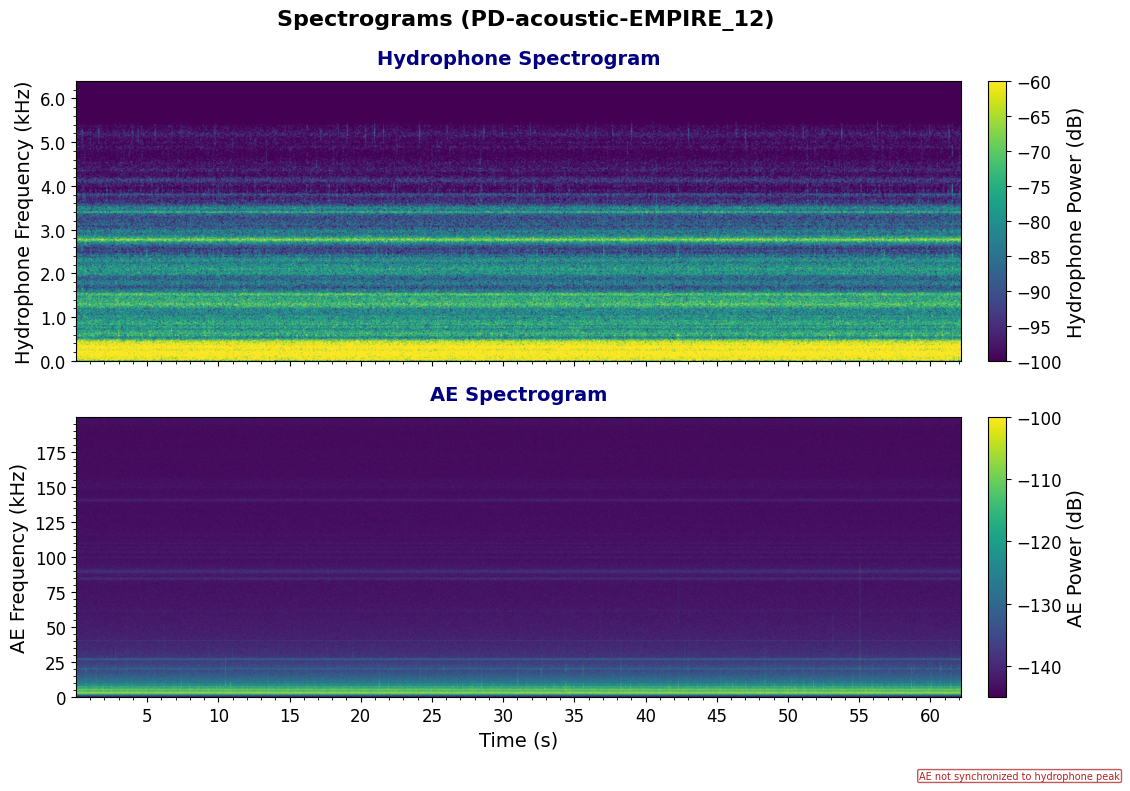

In [34]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1,1],
    hspace=0.20,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Top-left: Hydrophone spectrogram
cax1 = fig.add_subplot(gs[0, 1])              # Top-right: Hydrophone colorbar axis (aligned with spectrogram)
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)              # Bottom-left: AE spectrogram
cax2 = fig.add_subplot(gs[1, 1])             # Bottom-right: AE colorbar axis (aligned with spectrogram)

# --- Plot Hydrophone Spectrogram ---
im1 = ax1.imshow(
    hydrophone_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_sync_times[0],
        hydrophone_sync_times[-1],
        hydrophone_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax1.set_title('Hydrophone Spectrogram', fontsize=label_size, pad=12, fontweight='bold', color='navy')
ax1.set_ylabel('Hydrophone Frequency (kHz)', fontsize=label_size)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax1.tick_params(axis='y', which='major', labelsize=tick_size)
ax1.tick_params(axis='x', labelbottom=False)

# Attach hydrophone colorbar to the narrower cax1 axis
cbar = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

# --- Plot AE Spectrogram ---
im2 = ax2.imshow(
    ae_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        ae_sync_times[0],
        ae_sync_times[-1],
        ae_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        ae_masked_frequencies[-1] / 1e3
    ],
    vmin=min_ae_spectrogram_value_ctrl,
    vmax=max_ae_spectrogram_value_ctrl,
    cmap=ae_cmap,
    interpolation='bilinear'
)
ax2.set_title('AE Spectrogram', fontsize=label_size, pad=12, fontweight='bold', color='navy')
ax2.set_xlabel('Time (s)', fontsize=label_size)
ax2.set_ylabel('AE Frequency (kHz)', fontsize=label_size)
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax2.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach AE colorbar to the narrower cax2 axis
cbar = fig.colorbar(im2, cax=cax2, orientation='vertical')
cbar.set_label('AE Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.suptitle(
    f"Spectrograms ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.97
)

save_figure(fig, figure_suffix("AE_UnfilteredHydrophone_Spectrogram", trimmed_lvm_data, trimmed_ae_data, include_ae_spec=True, include_hydro_spec=True), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comparative\PD-acoustic-EMPIRE_12_AE_FilteredHydrophone_Spectrogram_start0s_end62.1619s_hp600Hz_aeMaxFreq200000Hz_aeMin-145_aeMax-100_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


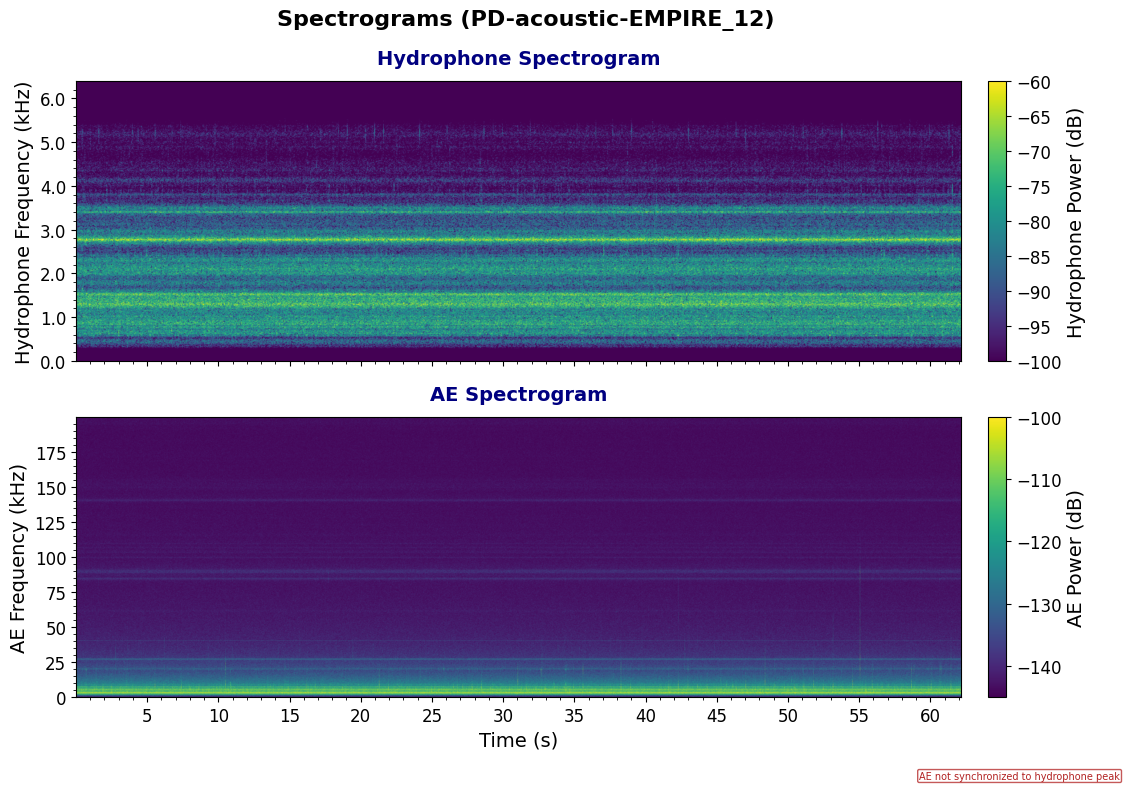

In [35]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[0.98, 0.02],   # relative widths for plots, colorbar
    height_ratios=[1,1],
    hspace=0.20,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])              # Top-left: Hydrophone spectrogram
cax1 = fig.add_subplot(gs[0, 1])              # Top-right: Hydrophone colorbar axis (aligned with spectrogram)
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)              # Bottom-left: AE spectrogram
cax2 = fig.add_subplot(gs[1, 1])             # Bottom-right: AE colorbar axis (aligned with spectrogram)

# --- Plot Hydrophone Spectrogram ---
im1 = ax1.imshow(
    hydrophone_hp_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_sync_times[0],
        hydrophone_sync_times[-1],
        hydrophone_hp_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_hp_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax1.set_title('Hydrophone Spectrogram', fontsize=label_size, pad=12, fontweight='bold', color='navy')
ax1.set_ylabel('Hydrophone Frequency (kHz)', fontsize=label_size)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax1.tick_params(axis='y', which='major', labelsize=tick_size)
ax1.tick_params(axis='x', labelbottom=False)

# Attach hydrophone colorbar to the narrower cax1 axis
cbar = fig.colorbar(im1, cax=cax1, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

# --- Plot AE Spectrogram ---
im2 = ax2.imshow(
    ae_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        ae_sync_times[0],
        ae_sync_times[-1],
        ae_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        ae_masked_frequencies[-1] / 1e3
    ],
    vmin=min_ae_spectrogram_value_ctrl,
    vmax=max_ae_spectrogram_value_ctrl,
    cmap=ae_cmap,
    interpolation='bilinear'
)
ax2.set_title('AE Spectrogram', fontsize=label_size, pad=12, fontweight='bold', color='navy')
ax2.set_xlabel('Time (s)', fontsize=label_size)
ax2.set_ylabel('AE Frequency (kHz)', fontsize=label_size)
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax2.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach AE colorbar to the narrower cax2 axis
cbar = fig.colorbar(im2, cax=cax2, orientation='vertical')
cbar.set_label('AE Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.suptitle(
    f"Spectrograms ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.97
)

hp_ae_spectrogram_comparative_path = save_figure(fig, figure_suffix("AE_FilteredHydrophone_Spectrogram", trimmed_high_pass_lvm_data, trimmed_ae_data, include_cutoff=True, include_ae_spec=True, include_hydro_spec=True), category="comparative", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comprehensive\PD-acoustic-EMPIRE_12_AE_Signal_RMS_Spectrogram_start0s_end62.1619s_aeMaxFreq200000Hz_aeMin-145_aeMax-100.png


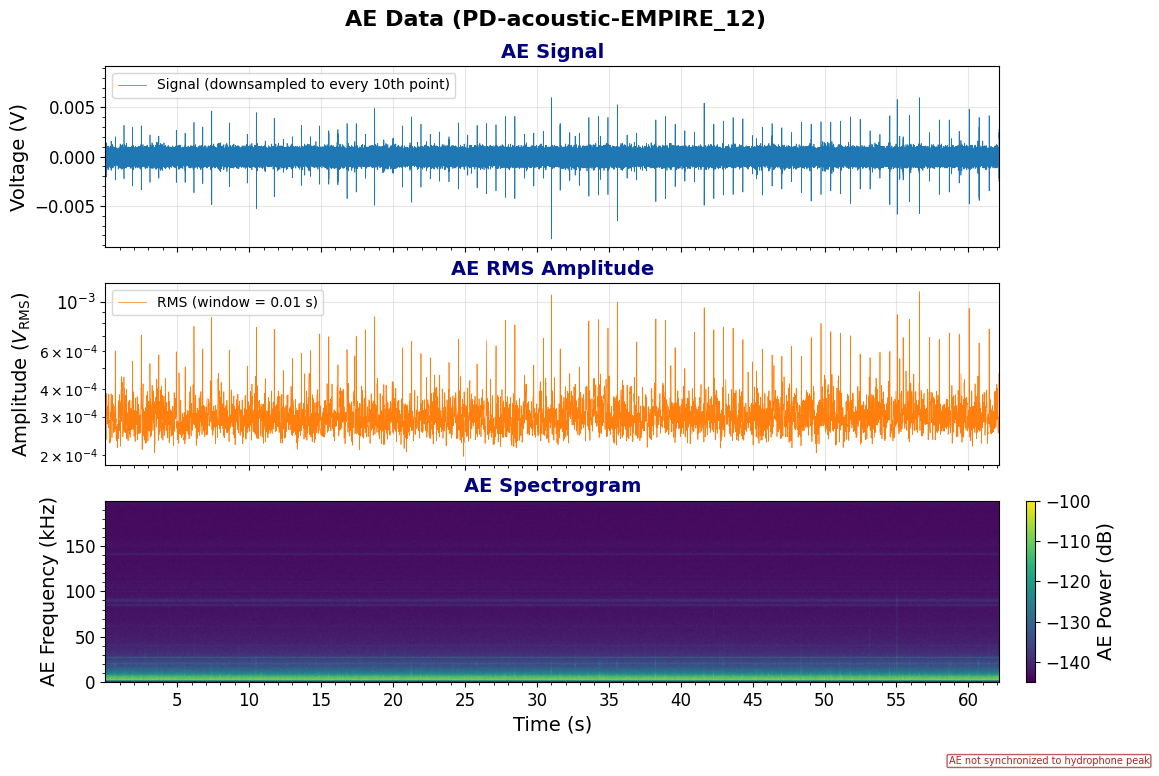

In [36]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[0.98, 0.01],   # relative widths for plots, colorbar
    height_ratios=[1,1,1],
    hspace=0.20,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])                          # Top-left: AE signal line plot
# cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)              # Middle-left: AE Amplitude line plot
# cax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)              # Bottom-left: AE Spectrogram
cax3 = fig.add_subplot(gs[2, 1])                         # Bottom-right: AE Spectrogram colorbar axis

# --- Plot AE Line Plot ---
ae_step = 10  # Plot every nth point to reduce rendering time; adjust as needed for performance vs. visual density
x_ds = trimmed_ae_data[::ae_step, 0]
y_ds = trimmed_ae_data[::ae_step, 1]

if ae_step == 1:
    label = "Signal"
else:
    if ae_step % 100 in (11, 12, 13):  # Special case for 11th, 12th, 13th
        suffix = "th"
    elif ae_step % 10 == 1:
        suffix = "st"
    elif ae_step % 10 == 2:
        suffix = "nd"
    elif ae_step % 10 == 3:
        suffix = "rd"
    else:
        suffix = "th"
    label = f"Signal (downsampled to every {ae_step}{suffix} point)"

ax1.plot(x_ds, y_ds, color='tab:blue', linewidth=0.5, label=label)
abs_max = np.max(np.abs(y_ds))
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.set_ylim(-abs_max*1.1, abs_max*1.1)
ax1.set_title('AE Signal', fontsize=label_size, fontweight='bold', color='navy')
ax1.set_ylabel('Voltage (V)', fontsize=label_size)
ax1.tick_params(axis='y', which='major', labelsize=tick_size)
ax1.tick_params(axis='x', labelbottom=False)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# --- Plot AE Amplitude (RMS) Line Plot ---
ax2.plot(ae_rms_times, ae_rms_values, color='tab:orange', linewidth=0.5, label=f"RMS (window = {ae_window_duration} s)")
ax2.set_title(f'AE RMS Amplitude', fontsize=label_size, fontweight='bold', color='navy')
ax2.set_yscale("log")
# ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.set_ylabel('RMS Amplitude (V)', fontsize=label_size)
ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax2.tick_params(axis='y', which='major', labelsize=tick_size)
ax2.tick_params(axis='x', labelbottom=False)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# --- Plot AE Spectrogram ---
im = ax3.imshow(
    ae_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        ae_sync_times[0],
        ae_sync_times[-1],
        ae_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        ae_masked_frequencies[-1] / 1e3
    ],
    vmin=min_ae_spectrogram_value_ctrl,
    vmax=max_ae_spectrogram_value_ctrl,
    cmap=ae_cmap,
    interpolation='bilinear'
)
ax3.set_title('AE Spectrogram', fontsize=label_size, fontweight='bold', color='navy')
ax3.yaxis.set_minor_locator(AutoMinorLocator())
ax3.set_xlabel('Time (s)', fontsize=label_size)
ax3.set_ylabel('AE Frequency (kHz)', fontsize=label_size)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax3.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach AE colorbar to the narrower cax3 axis
cbar = fig.colorbar(im, cax=cax3, orientation='vertical')
cbar.set_label('AE Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.suptitle(
    f"AE Data ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.95
)

ae_comprehensive_path = save_figure(fig, figure_suffix("AE_Signal_RMS_Spectrogram", trimmed_ae_data, include_ae_spec=True), category="comprehensive", dpi=figure_dpi, includes_ae=True)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comprehensive\PD-acoustic-EMPIRE_12_Hydrophone_Signal_RMS_Spectrogram_start0s_end62.1619s_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


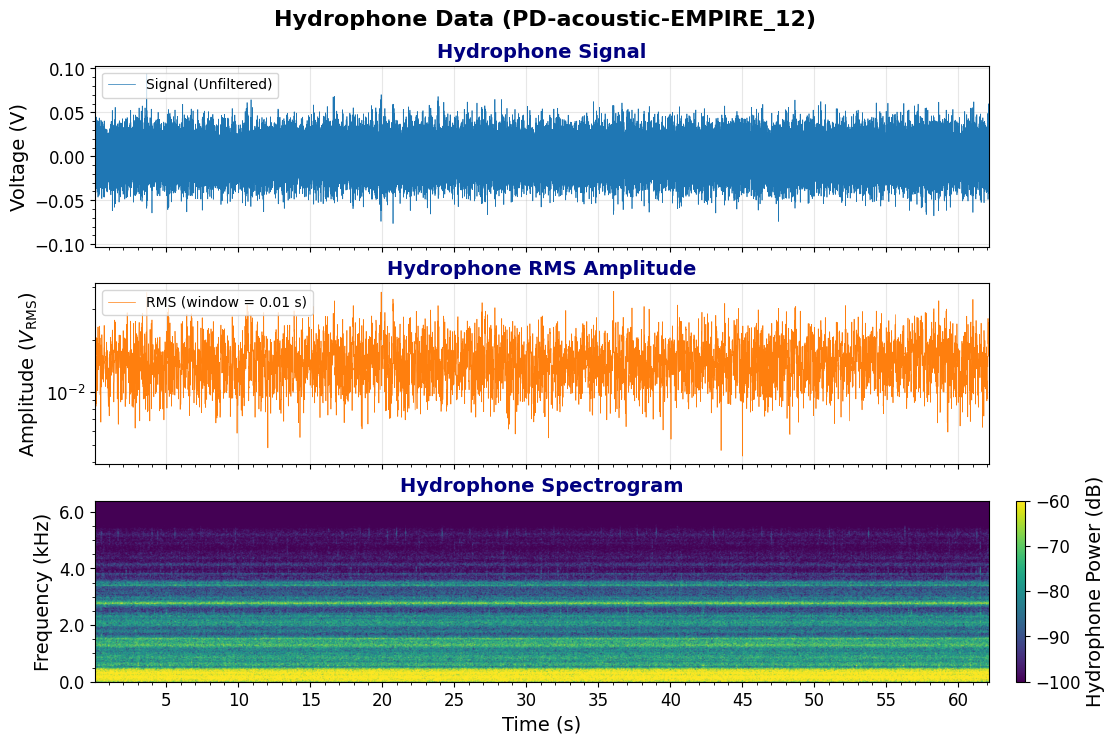

In [37]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[0.98, 0.01],   # relative widths for plots, colorbar
    height_ratios=[1,1,1],
    hspace=0.20,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])                          # Top-left: Hydrophone signal line plot
# cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)              # Middle-left: Hydrophone RMS Amplitude line plot
# cax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)              # Bottom-left: Hydrophone Spectrogram
cax3 = fig.add_subplot(gs[2, 1])                         # Bottom-right: Hydrophone Spectrogram colorbar axis

# --- Plot Hydrophone Line Plot ---
ax1.plot(trimmed_lvm_data[:, 0], trimmed_lvm_data[:, 1], color='tab:blue', linewidth=0.5, label=f'Signal (Unfiltered)')
abs_max = np.max(np.abs(trimmed_lvm_data[:, 1]))
ax1.set_ylim(-abs_max*1.1, abs_max*1.1)
ax1.set_title('Hydrophone Signal', fontsize=label_size, fontweight='bold', color='navy')
ax1.set_ylabel('Voltage (V)', fontsize=label_size)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis='y', which='major', labelsize=tick_size)
ax1.tick_params(axis='x', labelbottom=False)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# --- Plot Hydrophone Amplitude (RMS) Line Plot ---
ax2.plot(hydrophone_rms_times, hydrophone_rms_values, color='tab:orange', linewidth=0.5, label=f"RMS (window = {hydrophone_window_duration} s)")
ax2.set_title(f'Hydrophone RMS Amplitude', fontsize=label_size, fontweight='bold', color='navy')
ax2.set_yscale("log")
# ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax2.tick_params(axis='y', which='major', labelsize=tick_size)
ax2.tick_params(axis='x', labelbottom=False)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- Plot Hydrophone Spectrogram ---
im = ax3.imshow(
    hydrophone_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_sync_times[0],
        hydrophone_sync_times[-1],
        hydrophone_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax3.set_title('Hydrophone Spectrogram', fontsize=label_size, fontweight='bold', color='navy')
ax3.set_xlabel('Time (s)', fontsize=label_size)
ax3.set_ylabel('Frequency (kHz)', fontsize=label_size)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax3.yaxis.set_minor_locator(AutoMinorLocator())
ax3.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach Hydrophone colorbar to the narrower cax3 axis
cbar = fig.colorbar(im, cax=cax3, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.suptitle(
    f"Hydrophone Data ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.95
)

suffix = figure_suffix(
    "Hydrophone_Signal_RMS_Spectrogram",
    trimmed_lvm_data,
    include_hydro_spec=True,
)
save_figure(fig, suffix, category="comprehensive", dpi=figure_dpi)
plt.show()

Saved figure: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\imgs\comprehensive\PD-acoustic-EMPIRE_12_Filtered_Hydrophone_Signal_RMS_Spectrogram_start0s_end62.1619s_hp600Hz_hydroMaxFreq12000Hz_hydroMin-100_hydroMax-60.png


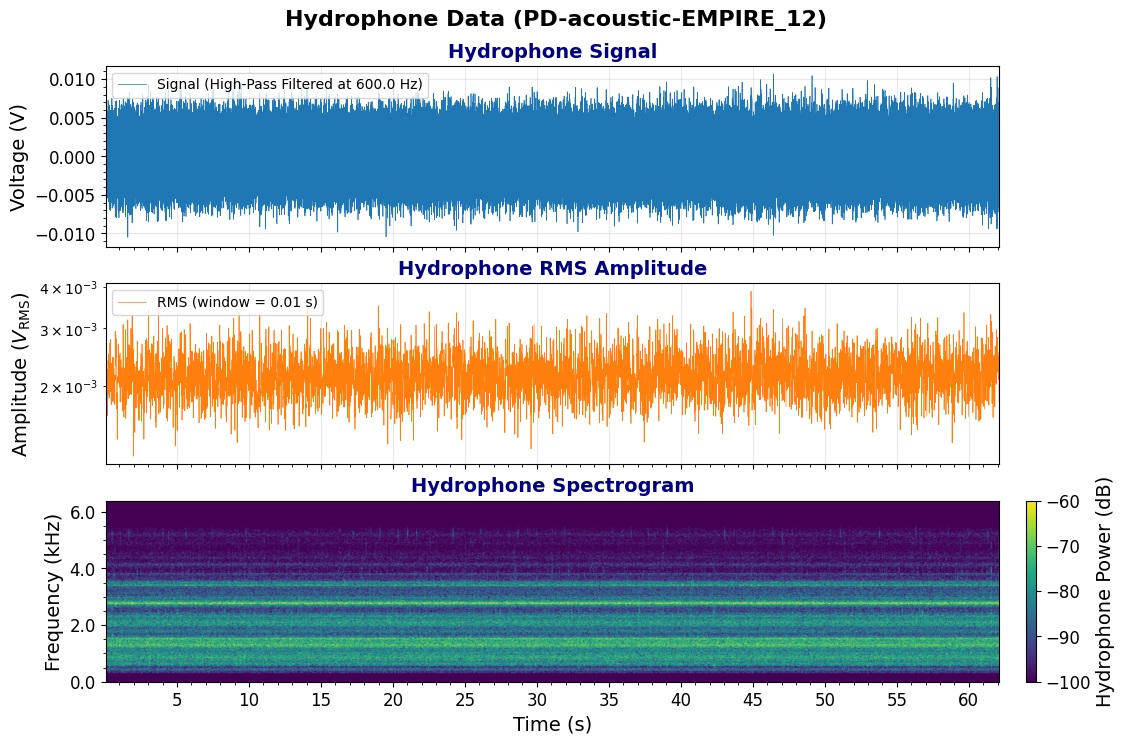

In [38]:
# Create a figure and GridSpec layout: left column for plots, right column for a narrower colorbar
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[0.98, 0.01],   # relative widths for plots, colorbar
    height_ratios=[1,1,1],
    hspace=0.20,
    wspace=0.06                  # Small horizontal gap between plots and colorbar
)

ax1 = fig.add_subplot(gs[0, 0])                          # Top-left: Hydrophone signal line plot
# cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)              # Middle-left: Hydrophone RMS Amplitude line plot
# cax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)              # Bottom-left: Hydrophone Spectrogram
cax3 = fig.add_subplot(gs[2, 1])                         # Bottom-right: Hydrophone Spectrogram colorbar axis

# --- Plot Hydrophone Line Plot ---
ax1.plot(trimmed_high_pass_lvm_data[:, 0], trimmed_high_pass_lvm_data[:, 1], color='tab:blue', linewidth=0.5, label=f'Signal (High-Pass Filtered at {cutoff_freq} Hz)')
abs_max = np.max(np.abs(trimmed_high_pass_lvm_data[:, 1]))
ax1.set_ylim(-abs_max*1.1, abs_max*1.1)
ax1.set_title('Hydrophone Signal', fontsize=label_size, fontweight='bold', color='navy')
ax1.set_ylabel('Voltage (V)', fontsize=label_size)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15, steps=[1, 2, 2.5, 5, 10]))
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(axis='y', which='major', labelsize=tick_size)
ax1.tick_params(axis='x', labelbottom=False)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# --- Plot Filtered Hydrophone Amplitude (RMS) Line Plot ---
ax2.plot(hydrophone_rms_times_hp, hydrophone_rms_values_hp, color='tab:orange', linewidth=0.5, label=f"RMS (window = {hydrophone_window_duration} s)")
ax2.set_title(f'Hydrophone RMS Amplitude', fontsize=label_size, fontweight='bold', color='navy')
ax2.set_yscale("log")
# ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.set_ylabel(r"Amplitude ($V_{\mathrm{RMS}}$)", fontsize=label_size)
ax2.tick_params(axis='y', which='major', labelsize=tick_size)
ax2.tick_params(axis='x', labelbottom=False)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- Plot Filtered Hydrophone Spectrogram ---
im = ax3.imshow(
    hydrophone_hp_masked_Sxx_log,
    aspect='auto',
    origin='lower',
    extent=[
        hydrophone_hp_sync_times[0],
        hydrophone_hp_sync_times[-1],
        hydrophone_hp_masked_frequencies[0] / 1e3,  # Convert to kHz for y-axis
        hydrophone_hp_masked_frequencies[-1] / 1e3
    ],
    vmin=min_hydro_spectrogram_value_ctrl,
    vmax=max_hydro_spectrogram_value_ctrl,
    cmap=hydro_cmap,
    interpolation='bilinear'
)
ax3.set_title('Hydrophone Spectrogram', fontsize=label_size, fontweight='bold', color='navy')
ax3.set_xlabel('Time (s)', fontsize=label_size)
ax3.set_ylabel('Frequency (kHz)', fontsize=label_size)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax3.yaxis.set_minor_locator(AutoMinorLocator())
ax3.tick_params(axis='both', which='major', labelsize=tick_size)

# Attach Hydrophone colorbar to the narrower cax3 axis
cbar = fig.colorbar(im, cax=cax3, orientation='vertical')
cbar.set_label('Hydrophone Power (dB)', fontsize=label_size)
cbar.ax.tick_params(labelsize=tick_size)

fig.suptitle(
    f"Hydrophone Data ({lvm_stem})", 
    fontsize=16, 
    fontweight='bold', 
    y=0.95
)

suffix = figure_suffix(
    "Filtered_Hydrophone_Signal_RMS_Spectrogram",
    trimmed_high_pass_lvm_data,
    include_cutoff=True,
    include_hydro_spec=True,
)
hp_hydrophone_comprehensive_path = save_figure(fig, suffix, category="comprehensive", dpi=figure_dpi)
plt.show()

# Create PowerPoint Slides

In [39]:
# Optional PowerPoint summary deck
make_powerpoint = input("Generate PowerPoint summary after saving plots? (y/n): ").strip().lower()

if make_powerpoint in {"y", "yes"}:
    try:
        from pptx import Presentation
        from pptx.enum.text import PP_ALIGN
        from pptx.util import Inches, Pt
        from PIL import Image
    except ImportError as exc:
        raise ImportError("Install python-pptx and Pillow to generate PowerPoint files: pip install python-pptx pillow") from exc

    pptx_dir = lvm_path.parent / "powerpoints"
    pptx_dir.mkdir(exist_ok=True)
    pptx_path = pptx_dir / f"{lvm_stem}_hydrophone_ae_summary.pptx"

    prs = Presentation()
    prs.slide_width = Inches(13.333)
    prs.slide_height = Inches(7.5)
    blank_layout = prs.slide_layouts[6]

    image_width = Inches(6.5)
    left_x = Inches(0.15)
    right_x = Inches(6.72)
    title_height = Inches(0.45)
    min_image_top = Inches(0.65)

    def image_height_at_width(image_path, width):
        with Image.open(image_path) as img:
            return int(width * img.height / img.width)

    def add_slide_with_images(title, left_image, right_image):
        slide = prs.slides.add_slide(blank_layout)

        title_box = slide.shapes.add_textbox(Inches(0.25), Inches(0.12), Inches(12.83), title_height)
        title_frame = title_box.text_frame
        title_frame.clear()
        paragraph = title_frame.paragraphs[0]
        paragraph.alignment = PP_ALIGN.CENTER
        run = paragraph.add_run()
        run.text = f"{title} ({lvm_stem})"
        run.font.size = Pt(22)
        run.font.bold = True

        left_height = image_height_at_width(left_image, image_width)
        right_height = image_height_at_width(right_image, image_width)
        group_height = max(left_height, right_height)
        image_top = max(min_image_top, int((prs.slide_height - group_height) / 2))

        slide.shapes.add_picture(str(left_image), left_x, image_top, width=image_width)
        slide.shapes.add_picture(str(right_image), right_x, image_top, width=image_width)

    required_images = {
        "High-pass hydrophone comprehensive figure": hp_hydrophone_comprehensive_path,
        "AE comprehensive figure": ae_comprehensive_path,
        "High-pass hydrophone + AE amplitude comparative figure": hp_ae_amplitude_comparative_path,
        "High-pass hydrophone + AE spectrogram comparative figure": hp_ae_spectrogram_comparative_path,
        "High-pass hydrophone spectrogram": hp_hydrophone_spectrogram_path,
        "AE spectrogram": ae_spectrogram_path,
    }
    missing_images = [name for name, path in required_images.items() if not Path(path).is_file()]
    if missing_images:
        raise FileNotFoundError("Missing images for PowerPoint: " + "; ".join(missing_images))

    add_slide_with_images(
        "Comprehensive Signals",
        hp_hydrophone_comprehensive_path,
        ae_comprehensive_path,
    )
    add_slide_with_images(
        "Comparative Amplitude and Spectrogram",
        hp_ae_amplitude_comparative_path,
        hp_ae_spectrogram_comparative_path,
    )
    add_slide_with_images(
        "Spectrogram Detail",
        hp_hydrophone_spectrogram_path,
        ae_spectrogram_path,
    )

    prs.save(pptx_path)
    print(f"Saved PowerPoint: {pptx_path}")
else:
    print("PowerPoint generation skipped.")


Saved PowerPoint: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_12\powerpoints\PD-acoustic-EMPIRE_12_hydrophone_ae_summary.pptx
